# ETS MARL — Priority 3: Tanh Saturation Fix

**P1 anti-convergence + P2 structural + P3: Clipped Gaussian & ε-Greedy**

This notebook is a testing playground for the ETS MARL simulation.
It clones the repository, installs dependencies, runs tests, trains agents,
and visualizes results — all within Google Colab.

---

### P3 Fixes (this experiment)
- **Clipped Gaussian** replaces tanh squashing in AuctionPolicy & SecondaryPolicy
  - `action = clamp(raw, -1, 1) * scale + bias` instead of `tanh(raw) * scale + bias`
  - Gradient = 1.0 inside bounds (vs tanh → 0.01 at boundaries)
  - Eliminates the absorbing state that trapped A2 at floor bid (40€)
- **Physical-space ε-greedy**: uniform random actions with P=ε
  - ε decays from 15% → 2% over 5000 episodes
  - Guarantees exploration of the full [40, 120]€ bid range
  - Raw action + log_prob computed under current policy for correct PPO ratios

### Model Overview (v5.0)
- **8 agents** representing European electricity utilities (10 TWh/year each)
  - 4 archetypes × 2 replicas: coal-heavy, gas-dominant, mixed, near-green
- **5 technologies**: Coal, Gas CCGT, Onshore Wind, Offshore Wind, Solar PV
- **Real-data-grounded** CapEx (IRENA 2024), emission factors (IPCC AR5), deployment delays
- **EU ETS mechanics**: uniform-price auction, MSR, LRF (Fit for 55), 100% auctioning
- **PPO agents** with two-phase decisions (auction + secondary market)
- **Greening-only** constraint: agents can only add renewables, fossil can only decrease
- **MAC fuel-switching**: automatic coal→gas dispatch switching at marginal cost (€65/tCO₂)
- **Electricity revenue**: margin-based reward (output × electricity price)
- **Carry-forward obligations**: non-compliance shortfall added to next year's surrender
- **Soft agent cycling**: all agents learn every episode (non-active at reduced LR)


In [1]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/DJH961/Thesis-Energy-Auction.git"
BRANCH = "Version_seven"
PROJECT_SUBDIR = "ets_marl ppo"

def _is_project_root(path: Path) -> bool:
    return (path / "src").is_dir() and (path / "configs").is_dir()

# Se hai indicato una repo, usa quella come fonte di verità
if REPO_URL:
    os.chdir("/content")

    repo_name = Path(REPO_URL.rstrip("/")).name.replace(".git", "")
    clone_dir = Path("/content") / repo_name

    if clone_dir.exists():
        print(f"Removing existing clone: {clone_dir}")
        subprocess.run(["rm", "-rf", str(clone_dir)], check=False)

    clone_cmd = ["git", "clone", "-b", BRANCH, REPO_URL, str(clone_dir)]
    print("Cloning:", " ".join(clone_cmd))
    subprocess.run(clone_cmd, check=True)

    # 1) prova esplicitamente la sottocartella richiesta
    if PROJECT_SUBDIR:
        target = clone_dir / PROJECT_SUBDIR
        if not _is_project_root(target):
            raise FileNotFoundError(
                f"PROJECT_SUBDIR non valido: {target}\n"
                f"Contenuto repo: {os.listdir(clone_dir)}"
            )
        os.chdir(target)
    else:
        # 2) altrimenti prova root repo, poi una cartella sotto
        candidates = [clone_dir] + [p for p in clone_dir.iterdir() if p.is_dir()]
        found = None
        for cand in candidates:
            if _is_project_root(cand):
                found = cand
                break
        if found is None:
            raise FileNotFoundError(
                f"Non trovo src/ e configs/ dentro {clone_dir}\n"
                f"Contenuto repo: {os.listdir(clone_dir)}"
            )
        os.chdir(found)

else:
    # fallback locale
    local_candidates = [Path("."), Path(".."), Path("../..")]
    found = None
    for cand in local_candidates:
        if _is_project_root(cand):
            found = cand
            break
    if found is None:
        raise FileNotFoundError(
            "Cannot find project root locally. Set REPO_URL in this cell."
        )
    os.chdir(found)

sys.path.insert(0, os.getcwd())
print("Working directory:", os.getcwd())
!git branch --show-current
!git log -1 --oneline
print("Files here:", os.listdir("."))

Cloning: git clone -b Version_seven https://github.com/DJH961/Thesis-Energy-Auction.git /content/Thesis-Energy-Auction
Working directory: /content/Thesis-Energy-Auction/ets_marl ppo
Version_seven
a85cdfc (HEAD -> Version_seven, origin/Version_seven) Add files via upload
Files here: ['setup.sh', 'scripts', 'results', 'main.py', 'uv.lock', 'notebooks', 'configs', 'pyproject.toml', 'tests', 'install.bat', 'README.md', 'docs', 'src', 'requirements.txt']


## 1. Setup — Clone Repository & Install Dependencies

In [2]:
# Install dependencies
if os.path.exists("requirements.txt"):
    !pip install -q -r requirements.txt
else:
    !pip install -q gymnasium numpy torch pyyaml pandas matplotlib seaborn pytest numpy-groupies

# Verify GPU availability
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 1.8 MB/s eta 0:00:00
PyTorch version: 2.10.0+cpu
CUDA available: False


In [3]:
# ── P3 Code Patches: Clipped Gaussian + Epsilon-Greedy ──
# Writes complete replacement files for actor_critic.py and ppo_agent.py.
# Applies targeted, verified patches to train.py.
# All changes include assertions that FAIL LOUDLY if something goes wrong.

import os

# ==============================================================
# 1. Write complete actor_critic.py (clamp replaces tanh)
# ==============================================================
AC_PATH = 'src/agents/actor_critic.py'
AC_CONTENT = r'''
"""
actor_critic.py
===============
PPO networks for two-phase ETS decisions:
  - AuctionPolicy:    obs_phase1 → 6 actions [bid_price, qty, invest_frac, tech_logits×3]
  - SecondaryPolicy:  obs_phase2 → 2 actions [sec_price_mult, sec_qty]
  - ValueNetwork:     obs_phase2 → scalar V(s)

All policies output Gaussian distributions (mean + learnable log_std).
Actions are clipped to [-1, 1] and rescaled to physical bounds.
Clipped Gaussian replaces tanh squashing to avoid gradient saturation at boundaries.

AuctionPolicy uses conditioned action heads: qty_mean is computed from
[hidden, price_mean.detach()] to encode the price→quantity dependency.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal


class AuctionPolicy(nn.Module):
    """
    Phase 1: obs → Gaussian over 6 auction actions.

    Conditioned heads architecture:
      price_head(hidden)                      → price_mean  (1D)
      qty_head(cat[hidden, price_mean.detach()]) → qty_mean (1D)
      rest_head(hidden)                       → [invest_frac, logit0, logit1, logit2] (4D)
    mean = cat[price_mean, qty_mean, rest_mean]  (6D)

    This encodes the structural dependency: bid quantity should adapt to bid price.
    The .detach() prevents gradients flowing back through price when training qty.
    """

    def __init__(self, obs_dim, action_dim, hidden_size, action_low, action_high,
                 log_std_min=-2.0, log_std_max=1.0):
        super().__init__()
        self.fc1 = nn.Linear(obs_dim, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)

        # Conditioned heads: price first, then qty conditioned on price
        self.price_head = nn.Linear(hidden_size, 1)
        self.qty_head = nn.Linear(hidden_size + 1, 1)   # +1 for price_mean signal
        # Remaining actions (invest_frac, 3 tech logits) stay independent
        self.rest_head = nn.Linear(hidden_size, action_dim - 2)

        self.log_std = nn.Parameter(torch.zeros(action_dim))
        self.log_std_min = log_std_min
        self.log_std_max = log_std_max

        self.register_buffer("action_scale", (action_high - action_low) / 2.0)
        self.register_buffer("action_bias", (action_high + action_low) / 2.0)
        self._init_weights()

    def _compute_mean(self, hidden):
        """Compute full action mean with price→qty conditioning."""
        price_mean = self.price_head(hidden)                                    # (B, 1)
        qty_mean = self.qty_head(torch.cat([hidden, price_mean.detach()], dim=-1))  # (B, 1)
        rest_mean = self.rest_head(hidden)                                      # (B, 4)
        return torch.cat([price_mean, qty_mean, rest_mean], dim=-1)             # (B, 6)

    def forward(self, obs):
        x = F.relu(self.fc1(obs))
        x = F.relu(self.fc2(x))
        mean = self._compute_mean(x)
        log_std_clamped = torch.clamp(self.log_std, self.log_std_min, self.log_std_max)
        std = log_std_clamped.exp().expand_as(mean)
        return Normal(mean, std)

    def act(self, obs, deterministic=False):
        """Returns (action_physical, raw_pretanh, log_prob)."""
        dist = self.forward(obs)
        if deterministic:
            raw = dist.mean
        else:
            raw = dist.rsample()

        # Clipped Gaussian: clamp to [-1, 1] instead of tanh.
        # Gradient = 1.0 inside bounds (vs tanh gradient → 0 at boundaries).
        squashed = torch.clamp(raw, -1.0, 1.0)
        action = squashed * self.action_scale + self.action_bias

        # No tanh log-prob correction needed: PPO importance ratio is correct
        # because both old and new log_probs use the same uncorrected formula.
        log_prob = dist.log_prob(raw).sum(dim=-1, keepdim=True)

        return action, raw, log_prob

    def evaluate(self, obs, raw_actions):
        """Given stored raw actions, recompute log_prob and entropy."""
        dist = self.forward(obs)
        log_prob = dist.log_prob(raw_actions).sum(dim=-1, keepdim=True)
        entropy = dist.entropy().sum(dim=-1, keepdim=True)
        return log_prob, entropy

    def _init_weights(self):
        for layer in [self.fc1, self.fc2]:
            nn.init.orthogonal_(layer.weight, gain=2**0.5)
            nn.init.zeros_(layer.bias)
        for head in [self.price_head, self.qty_head, self.rest_head]:
            nn.init.orthogonal_(head.weight, gain=0.01)
            nn.init.zeros_(head.bias)


class SecondaryPolicy(nn.Module):
    """Phase 2: obs_enriched(21) → Gaussian over 2 secondary actions."""

    def __init__(self, obs_dim, action_dim, hidden_size, action_low, action_high,
                 log_std_min=-2.0, log_std_max=1.0):
        super().__init__()
        self.fc1 = nn.Linear(obs_dim, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.mean_head = nn.Linear(hidden_size, action_dim)
        self.log_std = nn.Parameter(torch.zeros(action_dim))
        self.log_std_min = log_std_min
        self.log_std_max = log_std_max

        self.register_buffer("action_scale", (action_high - action_low) / 2.0)
        self.register_buffer("action_bias", (action_high + action_low) / 2.0)
        self._init_weights()

    def forward(self, obs):
        x = F.relu(self.fc1(obs))
        x = F.relu(self.fc2(x))
        mean = self.mean_head(x)
        log_std_clamped = torch.clamp(self.log_std, self.log_std_min, self.log_std_max)
        std = log_std_clamped.exp().expand_as(mean)
        return Normal(mean, std)

    def act(self, obs, deterministic=False):
        dist = self.forward(obs)
        if deterministic:
            raw = dist.mean
        else:
            raw = dist.rsample()

        # Clipped Gaussian: clamp instead of tanh (see AuctionPolicy.act).
        squashed = torch.clamp(raw, -1.0, 1.0)
        action = squashed * self.action_scale + self.action_bias

        log_prob = dist.log_prob(raw).sum(dim=-1, keepdim=True)

        return action, raw, log_prob

    def evaluate(self, obs, raw_actions):
        dist = self.forward(obs)
        log_prob = dist.log_prob(raw_actions).sum(dim=-1, keepdim=True)
        entropy = dist.entropy().sum(dim=-1, keepdim=True)
        return log_prob, entropy

    def _init_weights(self):
        for layer in [self.fc1, self.fc2]:
            nn.init.orthogonal_(layer.weight, gain=2**0.5)
            nn.init.zeros_(layer.bias)
        nn.init.orthogonal_(self.mean_head.weight, gain=0.01)
        nn.init.zeros_(self.mean_head.bias)


class ValueNetwork(nn.Module):
    """V(s) for PPO. Takes enriched obs(21) = full state."""

    def __init__(self, obs_dim, hidden_size):
        super().__init__()
        self.fc1 = nn.Linear(obs_dim, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)
        self._init_weights()

    def forward(self, obs):
        x = F.relu(self.fc1(obs))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

    def _init_weights(self):
        for layer in [self.fc1, self.fc2]:
            nn.init.orthogonal_(layer.weight, gain=2**0.5)
            nn.init.zeros_(layer.bias)
        nn.init.orthogonal_(self.fc3.weight, gain=1.0)
        nn.init.zeros_(self.fc3.bias)
'''

# Remove leading newline from triple-quote opening
if AC_CONTENT.startswith('\n'):
    AC_CONTENT = AC_CONTENT[1:]

with open(AC_PATH, 'w') as f:
    f.write(AC_CONTENT)

# Verify
with open(AC_PATH) as f:
    _ac = f.read()
assert 'torch.clamp(raw, -1.0, 1.0)' in _ac, 'FAIL: clamp not in actor_critic.py'
assert 'torch.tanh' not in _ac, 'FAIL: tanh still in actor_critic.py'
print(f'✅ Wrote {AC_PATH} ({_ac.count(chr(10))} lines)')

# ==============================================================
# 2. Write complete ppo_agent.py (epsilon-greedy exploration)
# ==============================================================
PPO_PATH = 'src/agents/ppo_agent.py'
PPO_CONTENT = r'''
"""
ppo_agent.py
============
PPO agent with two-phase decision making for EU ETS:
  Phase 1 (Auction):   obs(18) → [bid_price, qty, invest_frac, tech_logits×3]
  Phase 2 (Secondary): obs(21) → [sec_price_mult, sec_qty]

On-policy: collects full episode rollout, then updates via
clipped surrogate objective with GAE advantage estimation.

Supports **MAPPO** (Multi-Agent PPO) via centralized critic:
  When `ppo.centralized_critic = true`, the value network V(s) receives the
  global state (concatenation of all agents' phase-2 observations) instead of
  the local observation.  Actors remain decentralized (CTDE paradigm).

Roadmap improvements:
  P2: entropy_coef is updated externally via set_entropy_coef() (decay schedule
      lives in train.py so the agent stays stateless w.r.t. episode count).
  P3: RewardNormalizer tracks per-agent running mean/std with EMA.
      normalize_reward() normalises and clips before storing in buffer.
"""

import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import kl_divergence
from typing import Optional

from src.agents.actor_critic import AuctionPolicy, SecondaryPolicy, ValueNetwork


# ---------------------------------------------------------------------------
# P3: Per-agent running reward normaliser
# ---------------------------------------------------------------------------

class RewardNormalizer:
    """
    Online running mean/std normaliser using exponential moving average.

    reward_norm = (reward - mu) / (std + eps)

    Parameters
    ----------
    alpha : float
        EMA decay rate. alpha=0.01 ≈ window of 100 samples.
    eps : float
        Numerical stability floor for std.
    """

    def __init__(self, alpha: float = 0.01, eps: float = 1e-8):
        self.alpha = alpha
        self.eps = eps
        self.mu = 0.0
        self.var = 1.0     # initialise to 1 so first normalised value ≈ raw reward

    def update_and_normalize(self, reward: float) -> float:
        """Update running stats and return normalised reward (NOT clipped)."""
        # EMA mean
        self.mu = (1.0 - self.alpha) * self.mu + self.alpha * reward
        # EMA variance (using current reward before updating mean for stability)
        self.var = (1.0 - self.alpha) * self.var + self.alpha * (reward - self.mu) ** 2
        std = max(self.var ** 0.5, self.eps)
        return (reward - self.mu) / std

    def reset(self):
        """Optionally reset stats (not called by default — stats persist across episodes)."""
        self.mu = 0.0
        self.var = 1.0


# ---------------------------------------------------------------------------
# Rollout buffer
# ---------------------------------------------------------------------------

class RolloutBuffer:
    """Stores one episode of transitions for on-policy update."""

    def __init__(self):
        self.clear()

    def clear(self):
        self.obs1 = []
        self.obs2 = []
        self.global_states = []  # MAPPO: centralized critic input
        self.auction_raw = []
        self.secondary_raw = []
        self.auction_logp = []
        self.secondary_logp = []
        self.rewards = []
        self.dones = []
        self.values = []

    def push(self, obs1, obs2, auc_raw, sec_raw, auc_lp, sec_lp, reward, done, value,
             global_state=None):
        self.obs1.append(obs1)
        self.obs2.append(obs2)
        if global_state is not None:
            self.global_states.append(global_state)
        self.auction_raw.append(auc_raw)
        self.secondary_raw.append(sec_raw)
        self.auction_logp.append(auc_lp)
        self.secondary_logp.append(sec_lp)
        self.rewards.append(reward)
        self.dones.append(done)
        self.values.append(value)

    def __len__(self):
        return len(self.rewards)


# ---------------------------------------------------------------------------
# PPO Agent
# ---------------------------------------------------------------------------

class PPOAgent:

    def __init__(self, agent_id, obs_dim_phase1, obs_dim_phase2,
                 auction_action_low, auction_action_high,
                 secondary_action_low, secondary_action_high,
                 config, seed=None, global_state_dim=0):
        self.agent_id = agent_id
        self.config = config
        ppo = config["ppo"]

        self.gamma = ppo["gamma"]
        self.gae_lambda = ppo["gae_lambda"]
        self.clip_eps = ppo["clip_eps"]
        self.entropy_coef = ppo["entropy_coef"]  # P2: updated per-episode by train.py
        self.value_coef = ppo["value_coef"]
        self.max_grad_norm = ppo["max_grad_norm"]
        self.n_epochs = ppo["n_epochs"]
        self.mini_batch_size = ppo["mini_batch_size"]
        self.normalize_advantages = ppo.get("normalize_advantages", True)

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        hidden = ppo["hidden_size"]
        log_std_min = ppo.get("log_std_min", -2.0)
        log_std_max = ppo.get("log_std_max", 1.0)

        auction_dim = len(auction_action_low)
        secondary_dim = len(secondary_action_low)

        a_low = torch.FloatTensor(auction_action_low).to(self.device)
        a_high = torch.FloatTensor(auction_action_high).to(self.device)
        s_low = torch.FloatTensor(secondary_action_low).to(self.device)
        s_high = torch.FloatTensor(secondary_action_high).to(self.device)

        self.auction_policy = AuctionPolicy(
            obs_dim_phase1, auction_dim, hidden, a_low, a_high,
            log_std_min=log_std_min, log_std_max=log_std_max,
        ).to(self.device)

        self.secondary_policy = SecondaryPolicy(
            obs_dim_phase2, secondary_dim, hidden, s_low, s_high,
            log_std_min=log_std_min, log_std_max=log_std_max,
        ).to(self.device)

        # MAPPO: centralized critic sees global state (all agents' obs2 concatenated)
        self.centralized_critic = ppo.get("centralized_critic", False)
        critic_hidden = ppo.get("critic_hidden_size", hidden)

        if self.centralized_critic and global_state_dim > 0:
            self.value_net = ValueNetwork(global_state_dim, critic_hidden).to(self.device)
        else:
            self.value_net = ValueNetwork(obs_dim_phase2, hidden).to(self.device)

        all_params = (
            list(self.auction_policy.parameters()) +
            list(self.secondary_policy.parameters()) +
            list(self.value_net.parameters())
        )
        self.optimizer = optim.Adam(all_params, lr=ppo["lr"])

        self.buffer = RolloutBuffer()
        self.actor_loss_history = []
        self.critic_loss_history = []

        # P3: per-agent reward normaliser
        reward_cfg = config.get("reward", {})
        norm_alpha = reward_cfg.get("normalizer_alpha", 0.01)
        self._reward_normalizer = RewardNormalizer(alpha=norm_alpha)
        self._reward_clip_min = reward_cfg.get("clip_min", -10.0)
        self._reward_clip_max = reward_cfg.get("clip_max", 2.0)

        # KL anchor: frozen snapshot of BC-trained policy (set after BC pretraining)
        self._bc_auction_policy = None
        self._bc_secondary_policy = None
        self.kl_beta = 0.0

    # ------------------------------------------------------------------
    # P2: Entropy coefficient update (called by train.py)
    # ------------------------------------------------------------------

    def set_entropy_coef(self, coef: float):
        """Update entropy coefficient for this training step (P2 decay schedule)."""
        self.entropy_coef = float(coef)

    def set_kl_beta(self, beta: float):
        """Update KL anchor penalty weight (decayed by train.py)."""
        self.kl_beta = float(beta)

    def set_bc_anchor(self):
        """
        Snapshot current auction and secondary policy weights as a frozen
        BC anchor.  Called by train.py immediately after BC pretraining.
        The anchor networks receive no gradient updates.
        """
        self._bc_auction_policy = copy.deepcopy(self.auction_policy).eval()
        for p in self._bc_auction_policy.parameters():
            p.requires_grad_(False)

        self._bc_secondary_policy = copy.deepcopy(self.secondary_policy).eval()
        for p in self._bc_secondary_policy.parameters():
            p.requires_grad_(False)

    # ------------------------------------------------------------------
    # P3: Reward normalisation
    # ------------------------------------------------------------------

    def normalize_reward(self, reward: float) -> float:
        """
        Normalise reward with per-agent running stats, then clip.
        Called by the training loop before storing transitions.
        """
        r_norm = self._reward_normalizer.update_and_normalize(reward)
        return float(np.clip(r_norm, self._reward_clip_min, self._reward_clip_max))

    # ------------------------------------------------------------------
    # Action selection
    # ------------------------------------------------------------------

    def select_auction_action(self, obs1: np.ndarray, deterministic=False,
                              epsilon: float = 0.0):
        """Phase 1: obs(18) → (action[6], raw[6], logp[1]).

        When ``epsilon > 0`` and not deterministic, with probability *epsilon*
        a uniform random action in physical space replaces the policy sample.
        The raw action and log_prob are still computed under the current policy
        so that the PPO importance ratio remains correct.
        """
        obs_t = torch.FloatTensor(obs1).unsqueeze(0).to(self.device)
        with torch.no_grad():
            action, raw, log_prob = self.auction_policy.act(obs_t, deterministic)

        if not deterministic and epsilon > 0.0 and np.random.random() < epsilon:
            with torch.no_grad():
                # Uniform random action in physical [low, high] space
                low = self.auction_policy.action_bias - self.auction_policy.action_scale
                high = self.auction_policy.action_bias + self.auction_policy.action_scale
                rand_action = torch.rand_like(action) * (high - low) + low
                # Convert to raw (normalised) space
                rand_raw = torch.clamp(
                    (rand_action - self.auction_policy.action_bias) /
                    (self.auction_policy.action_scale + 1e-8), -1.0, 1.0)
                # Log-prob under current policy (for PPO importance ratio)
                dist = self.auction_policy.forward(obs_t)
                rand_lp = dist.log_prob(rand_raw).sum(dim=-1, keepdim=True)
            return (rand_action.cpu().numpy().squeeze(0),
                    rand_raw.cpu().numpy().squeeze(0),
                    rand_lp.cpu().numpy().squeeze(0))

        return (action.cpu().numpy().squeeze(0),
                raw.cpu().numpy().squeeze(0),
                log_prob.cpu().numpy().squeeze(0))

    def select_secondary_action(self, obs2: np.ndarray, deterministic=False,
                                epsilon: float = 0.0):
        """Phase 2: obs(21) → (action[2], raw[2], logp[1]).

        Epsilon-greedy in physical space (same approach as auction actions).
        """
        obs_t = torch.FloatTensor(obs2).unsqueeze(0).to(self.device)
        with torch.no_grad():
            action, raw, log_prob = self.secondary_policy.act(obs_t, deterministic)

        if not deterministic and epsilon > 0.0 and np.random.random() < epsilon:
            with torch.no_grad():
                low = self.secondary_policy.action_bias - self.secondary_policy.action_scale
                high = self.secondary_policy.action_bias + self.secondary_policy.action_scale
                rand_action = torch.rand_like(action) * (high - low) + low
                rand_raw = torch.clamp(
                    (rand_action - self.secondary_policy.action_bias) /
                    (self.secondary_policy.action_scale + 1e-8), -1.0, 1.0)
                dist = self.secondary_policy.forward(obs_t)
                rand_lp = dist.log_prob(rand_raw).sum(dim=-1, keepdim=True)
            return (rand_action.cpu().numpy().squeeze(0),
                    rand_raw.cpu().numpy().squeeze(0),
                    rand_lp.cpu().numpy().squeeze(0))

        return (action.cpu().numpy().squeeze(0),
                raw.cpu().numpy().squeeze(0),
                log_prob.cpu().numpy().squeeze(0))

    def estimate_value(self, obs: np.ndarray) -> float:
        """V(s) — from local obs2 (IPPO) or global state (MAPPO)."""
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(self.device)
        with torch.no_grad():
            return self.value_net(obs_t).cpu().item()

    # ------------------------------------------------------------------
    # Storage
    # ------------------------------------------------------------------

    def store_transition(self, obs1, obs2, auc_raw, sec_raw,
                         auc_lp, sec_lp, reward, done, value,
                         global_state=None):
        self.buffer.push(obs1, obs2, auc_raw, sec_raw,
                         auc_lp, sec_lp, reward, done, value,
                         global_state=global_state)

    # ------------------------------------------------------------------
    # PPO Update (end of episode)
    # ------------------------------------------------------------------

    def update(self, last_value: float = 0.0, actor_update: bool = True) -> Optional[dict]:
        """
        PPO update for one episode rollout.

        Parameters
        ----------
        last_value : float
            Bootstrap value for the last step (0 if terminal).
        actor_update : bool
            When False (critic-warmup phase) only the value network is trained;
            actor gradients are not computed or applied.
        """
        if len(self.buffer) < 2:
            return None

        obs1 = torch.FloatTensor(np.array(self.buffer.obs1)).to(self.device)
        obs2 = torch.FloatTensor(np.array(self.buffer.obs2)).to(self.device)

        # MAPPO: use global states for centralized critic if available
        if self.centralized_critic and len(self.buffer.global_states) > 0:
            critic_input = torch.FloatTensor(
                np.array(self.buffer.global_states)).to(self.device)
        else:
            critic_input = obs2

        auc_raw = torch.FloatTensor(np.array(self.buffer.auction_raw)).to(self.device)
        sec_raw = torch.FloatTensor(np.array(self.buffer.secondary_raw)).to(self.device)
        old_auc_lp = torch.FloatTensor(np.array(self.buffer.auction_logp)).to(self.device)
        old_sec_lp = torch.FloatTensor(np.array(self.buffer.secondary_logp)).to(self.device)
        rewards = np.array(self.buffer.rewards, dtype=np.float32)
        dones = np.array(self.buffer.dones, dtype=np.float32)
        values = np.array(self.buffer.values, dtype=np.float32)

        # GAE (P2: gae_lambda = 0.97 in config for longer credit assignment)
        T = len(rewards)
        advantages = np.zeros(T, dtype=np.float32)
        gae = 0.0
        for t in reversed(range(T)):
            next_val = last_value if t == T - 1 else values[t + 1]
            delta = rewards[t] + self.gamma * (1 - dones[t]) * next_val - values[t]
            gae = delta + self.gamma * self.gae_lambda * (1 - dones[t]) * gae
            advantages[t] = gae

        returns = advantages + values
        adv_t = torch.FloatTensor(advantages).to(self.device).unsqueeze(1)
        ret_t = torch.FloatTensor(returns).to(self.device).unsqueeze(1)

        if self.normalize_advantages and T > 1:
            adv_t = (adv_t - adv_t.mean()) / (adv_t.std() + 1e-8)

        # PPO epochs
        total_a_loss = 0.0
        total_v_loss = 0.0
        n_up = 0

        for _ in range(self.n_epochs):
            idx = np.arange(T)
            np.random.shuffle(idx)

            for start in range(0, T, self.mini_batch_size):
                end = min(start + self.mini_batch_size, T)
                mb = idx[start:end]

                v_pred = self.value_net(critic_input[mb])
                value_loss = nn.MSELoss()(v_pred, ret_t[mb])

                if actor_update:
                    # Re-evaluate current policy
                    auc_lp_new, auc_ent = self.auction_policy.evaluate(obs1[mb], auc_raw[mb])
                    sec_lp_new, sec_ent = self.secondary_policy.evaluate(obs2[mb], sec_raw[mb])

                    # Per-policy PPO clipping: decomposes the joint ratio so each
                    # policy's gradient update is independently clipped.  Prevents
                    # a profitable secondary trade from incorrectly reinforcing
                    # bad auction bids (and vice versa).
                    auc_ratio = torch.exp(auc_lp_new - old_auc_lp[mb])
                    auc_surr1 = auc_ratio * adv_t[mb]
                    auc_surr2 = torch.clamp(auc_ratio, 1 - self.clip_eps, 1 + self.clip_eps) * adv_t[mb]
                    auc_policy_loss = -torch.min(auc_surr1, auc_surr2).mean()

                    sec_ratio = torch.exp(sec_lp_new - old_sec_lp[mb])
                    sec_surr1 = sec_ratio * adv_t[mb]
                    sec_surr2 = torch.clamp(sec_ratio, 1 - self.clip_eps, 1 + self.clip_eps) * adv_t[mb]
                    sec_policy_loss = -torch.min(sec_surr1, sec_surr2).mean()

                    policy_loss = auc_policy_loss + sec_policy_loss

                    # P2: entropy_coef updated externally via set_entropy_coef()
                    entropy = (auc_ent + sec_ent).mean()

                    # KL anchor penalty against frozen BC policy
                    kl_pen = torch.tensor(0.0, device=self.device)
                    if self._bc_auction_policy is not None and self.kl_beta > 0.0:
                        curr_auc_dist = self.auction_policy.forward(obs1[mb])
                        curr_sec_dist = self.secondary_policy.forward(obs2[mb])
                        with torch.no_grad():
                            bc_auc_dist = self._bc_auction_policy.forward(obs1[mb])
                            bc_sec_dist = self._bc_secondary_policy.forward(obs2[mb])
                        kl_auc = kl_divergence(curr_auc_dist, bc_auc_dist).mean()
                        kl_sec = kl_divergence(curr_sec_dist, bc_sec_dist).mean()
                        kl_pen = self.kl_beta * (kl_auc + kl_sec) * 0.5

                    loss = (policy_loss
                            + self.value_coef * value_loss
                            - self.entropy_coef * entropy
                            + kl_pen)
                else:
                    # Critic-warmup: train value network only
                    policy_loss = torch.tensor(0.0, device=self.device)
                    loss = self.value_coef * value_loss

                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(
                    list(self.auction_policy.parameters()) +
                    list(self.secondary_policy.parameters()) +
                    list(self.value_net.parameters()),
                    self.max_grad_norm
                )
                self.optimizer.step()

                total_a_loss += policy_loss.item()
                total_v_loss += value_loss.item()
                n_up += 1

        self.buffer.clear()

        avg_a = total_a_loss / max(n_up, 1)
        avg_v = total_v_loss / max(n_up, 1)
        self.actor_loss_history.append(avg_a)
        self.critic_loss_history.append(avg_v)
        return {"actor_loss": avg_a, "critic_loss": avg_v}

    # ------------------------------------------------------------------
    # Save / Load
    # ------------------------------------------------------------------

    def save(self, path):
        torch.save({
            "auction_policy": self.auction_policy.state_dict(),
            "secondary_policy": self.secondary_policy.state_dict(),
            "value_net": self.value_net.state_dict(),
        }, path)

    def load(self, path):
        ckpt = torch.load(path, map_location=self.device)
        self.auction_policy.load_state_dict(ckpt["auction_policy"])
        self.secondary_policy.load_state_dict(ckpt["secondary_policy"])
        self.value_net.load_state_dict(ckpt["value_net"])
'''

if PPO_CONTENT.startswith('\n'):
    PPO_CONTENT = PPO_CONTENT[1:]

with open(PPO_PATH, 'w') as f:
    f.write(PPO_CONTENT)

with open(PPO_PATH) as f:
    _ppo = f.read()
assert 'epsilon: float = 0.0' in _ppo, 'FAIL: epsilon not in ppo_agent.py'
assert _ppo.count('epsilon: float = 0.0') == 2, 'FAIL: expected 2 epsilon params'
print(f'✅ Wrote {PPO_PATH} ({_ppo.count(chr(10))} lines)')

# ==============================================================
# 3. Patch train.py (targeted changes with assertion guards)
# ==============================================================
TRAIN_PATH = 'scripts/train.py'
with open(TRAIN_PATH) as f:
    code = f.read()

# --- 3a. Rename _to_pretanh → _to_raw ---
n = code.count('_to_pretanh')
assert n >= 2, f'Expected >=2 _to_pretanh, found {n}'
code = code.replace('_to_pretanh', '_to_raw')
assert '_to_pretanh' not in code
print(f'  ✅ 3a. Renamed _to_pretanh → _to_raw ({n} occurrences)')

# --- 3b. Replace atanh → clamp in _to_raw body ---
assert 'torch.atanh' in code, 'FAIL: torch.atanh not in train.py'
code = code.replace(
    'normalized = torch.clamp((h_t - bias) / (scale + 1e-8), -1.0 + 1e-6, 1.0 - 1e-6)\n'
    '    return torch.atanh(normalized).cpu().numpy()',
    'return torch.clamp((h_t - bias) / (scale + 1e-8), -1.0, 1.0).cpu().numpy()'
)
assert 'torch.atanh' not in code, 'FAIL: atanh replacement failed'
print('  ✅ 3b. Replaced atanh → clamp in _to_raw body')

# --- 3c. Add epsilon schedule config after curriculum ---
CURSOR_C = '# Condition-based entropy tracker'
assert CURSOR_C in code, f"FAIL: '{CURSOR_C}' not found"
eps_init = (
    '# Epsilon-greedy exploration schedule (physical-space)\n'
    '    explore_cfg = config.get("exploration", {})\n'
    '    eps_start = explore_cfg.get("epsilon_start", 0.0)\n'
    '    eps_final = explore_cfg.get("epsilon_final", 0.0)\n'
    '    eps_decay_episodes = explore_cfg.get("epsilon_decay_episodes", 5000)\n'
    '    if eps_start > 0.0:\n'
    '        print(f"Epsilon-greedy: {eps_start:.2f} \\u2192 {eps_final:.2f} "\n'
    '              f"over {eps_decay_episodes} episodes (physical-space).")\n'
    '\n'
    '    ')
code = code.replace(CURSOR_C, eps_init + CURSOR_C)
assert 'eps_start' in code
print('  ✅ 3c. Added epsilon schedule config')

# --- 3d. Add epsilon computation in episode loop ---
CURSOR_D = 'obs1, _ = env.reset(seed=seed + episode * 1000)'
assert CURSOR_D in code, f"FAIL: '{CURSOR_D}' not found"
eps_compute = (
    '# Epsilon-greedy schedule: linear decay\n'
    '        if eps_start > 0.0:\n'
    '            eps_frac = min(1.0, episode / max(eps_decay_episodes, 1))\n'
    '            current_epsilon = eps_start + eps_frac * (eps_final - eps_start)\n'
    '        else:\n'
    '            current_epsilon = 0.0\n'
    '\n'
    '        ')
code = code.replace(CURSOR_D, eps_compute + CURSOR_D)
assert 'current_epsilon' in code
print('  ✅ 3d. Added epsilon computation')

# --- 3e. Pass epsilon to action selection ---
old_auc = 'agents[i].select_auction_action(obs1[i])'
assert old_auc in code, f"FAIL: '{old_auc}' not found"
code = code.replace(old_auc,
    'agents[i].select_auction_action(\n                    obs1[i], epsilon=current_epsilon)')
old_sec = 'agents[i].select_secondary_action(obs2[i])'
assert old_sec in code, f"FAIL: '{old_sec}' not found"
code = code.replace(old_sec,
    'agents[i].select_secondary_action(\n                    obs2[i], epsilon=current_epsilon)')
print('  ✅ 3e. Added epsilon= to action selection calls')

# --- 3f. Add epsilon to CSV ep_fields ---
assert '"active_agent"]' in code, 'FAIL: ep_fields active_agent not found'
code = code.replace('"active_agent"]', '"active_agent",\n                 "epsilon"]')
print('  ✅ 3f. Added epsilon to CSV fields')

# --- 3g. Add epsilon to ep_row ---
CURSOR_G = '"active_agent": active_agent_idx if cycling_enabled else -1,'
assert CURSOR_G in code, 'FAIL: ep_row active_agent not found'
code = code.replace(CURSOR_G, CURSOR_G + '\n            "epsilon": round(current_epsilon, 4),')
print('  ✅ 3g. Added epsilon to ep_row')

# --- 3h. Add eps= to console logging ---
CURSOR_H = 'shp={env.shaping_weight:.3f}"'
assert CURSOR_H in code, 'FAIL: shp logging cursor not found'
code = code.replace(CURSOR_H, 'shp={env.shaping_weight:.3f}  eps={current_epsilon:.3f}"')
print('  ✅ 3h. Added eps= to console logging')

# --- Write patched train.py ---
with open(TRAIN_PATH, 'w') as f:
    f.write(code)

# Final verification
with open(TRAIN_PATH) as f:
    final = f.read()
checks = {
    '_to_raw present': '_to_raw' in final,
    'no atanh': 'torch.atanh' not in final,
    'no _to_pretanh': '_to_pretanh' not in final,
    'eps_start': 'eps_start' in final,
    'current_epsilon': 'current_epsilon' in final,
    'epsilon=current_epsilon': 'epsilon=current_epsilon' in final,
    'epsilon CSV': '"epsilon"' in final,
    'eps logging': 'eps={current_epsilon' in final,
}
all_ok = all(checks.values())
for k, v in checks.items():
    print(f'  {chr(9989) if v else chr(10060)} {k}')
assert all_ok, f'FAILED: {[k for k,v in checks.items() if not v]}'
print(f'\n✅ Patched {TRAIN_PATH} — all {len(checks)} checks passed')

print()
print('=' * 60)
print('P3 CODE PATCHES COMPLETE')
print('  • actor_critic.py: full rewrite (clamp, no tanh)')
print('  • ppo_agent.py:    full rewrite (epsilon-greedy)')
print('  • train.py:        targeted patches (8 verified)')
print('=' * 60)


✅ Patched src/agents/actor_critic.py: tanh → clamp, removed log-prob correction
✅ Patched scripts/train.py: _to_pretanh → _to_raw (no atanh)
✅ Patched src/agents/ppo_agent.py: added epsilon-greedy to select_*_action()
✅ Patched scripts/train.py: epsilon schedule + pass-through

✅ All P3 code patches applied successfully.


## 2. Run Tests — Verify Everything Works

In [4]:
!python -m pytest tests/ -v

============================= test session starts ==============================
platform linux -- Python 3.12.12, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/Thesis-Energy-Auction/ets_marl ppo
configfile: pyproject.toml
plugins: anyio-4.12.1, langsmith-0.7.13, typeguard-4.5.1
collected 66 items                                                             

tests/test_cap_schedule.py::test_cap_year_0 PASSED                       [  1%]
tests/test_cap_schedule.py::test_cap_year_1_lrf_phase1 PASSED            [  3%]
tests/test_cap_schedule.py::test_cap_year_5_switches_to_phase2 PASSED    [  4%]
tests/test_cap_schedule.py::test_cap_strictly_decreasing PASSED          [  6%]
tests/test_cap_schedule.py::test_cap_year_10 PASSED                      [  7%]
tests/test_cap_schedule.py::test_msr_no_adjustment_within_band PASSED    [  9%]
tests/test_cap_schedule.py::test_msr_withhold_when_tnac_high PASSED      [ 10%]
tests/test_cap_schedule.py::test_msr

## 3. Explore the Environment

In [5]:
import os, yaml
print("CWD:", os.getcwd())

with open("configs/default.yaml") as f:
    config = yaml.safe_load(f)

print("Config keys:", list(config.keys()))

CWD: /content/Thesis-Energy-Auction/ets_marl ppo
Config keys: ['simulation', 'technologies', 'ets', 'companies', 'investment', 'risk', 'auction', 'trading', 'budget', 'penalty', 'price', 'mac', 'electricity', 'reward', 'opponent_modeling', 'agent_cycling', 'ppo', 'curriculum', 'uncertainty', 'construction_jitter', 'warm_start', 'logging', 'pretrain', 'diagnostics', 'exploration']


In [6]:
import sys
sys.path.insert(0, '.')

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.environment.ets_environment import ETSEnvironment

with open('configs/default.yaml') as f:
    config = yaml.safe_load(f)

env = ETSEnvironment(config, seed=42)
obs1, _ = env.reset()

tech_names = config['technologies']['names']

print('=== Environment Summary ===')
print(f'Agents: {env.n_agents}')
print(f'Years: {env.n_years}')
print(f'Technologies: {tech_names}')
print(f'Phase 1 obs dim: {obs1.shape[1]}')
print(f'Initial cap: {env.cap_schedule.get_cap(0):.2f} Mt')
print()

for i, c in enumerate(env.companies):
    mix_str = ' | '.join([f'{tech_names[t]}: {c.mix[t]*100:.0f}%' for t in range(len(tech_names))])
    print(f'A{i+1}: {mix_str}')
    print(f'     Emissions: {c.compute_emissions():.2f} Mt | '
          f'Green: {c.green_frac*100:.0f}% | '
          f'Op. Cost: {c.compute_operational_cost():.0f} M€/yr | '
          f'Avg EF: {c.weighted_emission_factor:.3f} tCO2/MWh')


=== Environment Summary ===
Agents: 8
Years: 12
Technologies: ['coal', 'gas', 'onshore_wind', 'offshore_wind', 'solar']
Phase 1 obs dim: 35
Initial cap: 24.00 Mt

A1: coal: 40% | gas: 40% | onshore_wind: 10% | offshore_wind: 5% | solar: 5%
     Emissions: 5.28 Mt | Green: 20% | Op. Cost: 554 M€/yr | Avg EF: 0.528 tCO2/MWh
A2: coal: 40% | gas: 40% | onshore_wind: 10% | offshore_wind: 5% | solar: 5%
     Emissions: 5.28 Mt | Green: 20% | Op. Cost: 554 M€/yr | Avg EF: 0.528 tCO2/MWh
A3: coal: 15% | gas: 45% | onshore_wind: 20% | offshore_wind: 10% | solar: 10%
     Emissions: 3.52 Mt | Green: 40% | Op. Cost: 446 M€/yr | Avg EF: 0.352 tCO2/MWh
A4: coal: 15% | gas: 45% | onshore_wind: 20% | offshore_wind: 10% | solar: 10%
     Emissions: 3.52 Mt | Green: 40% | Op. Cost: 446 M€/yr | Avg EF: 0.352 tCO2/MWh
A5: coal: 5% | gas: 25% | onshore_wind: 35% | offshore_wind: 20% | solar: 15%
     Emissions: 1.77 Mt | Green: 70% | Op. Cost: 342 M€/yr | Avg EF: 0.177 tCO2/MWh
A6: coal: 5% | gas: 25% | o

## 4. Run a Random-Policy Episode (Baseline)

In [7]:
env = ETSEnvironment(config, seed=42)
obs1, _ = env.reset(seed=42)
n_agents = env.n_agents
rng = np.random.default_rng(42)

aq = config['auction']
inv = config['investment']
trading_cfg = config.get('trading', {})
qty_mult_low = aq.get('qty_mult_low', 0.3)
qty_mult_high = aq.get('qty_mult_high', 1.3)
sec_mult_low = trading_cfg.get('sec_mult_low', 0.8)
sec_mult_high = trading_cfg.get('sec_mult_high', 1.3)

year_data = []

for year in range(config['simulation']['n_years']):
    # Random auction actions (use config bounds)
    auction_actions = rng.uniform(
        [aq['price_min'], qty_mult_low, 0.0, -1.0, -1.0, -1.0],
        [aq['price_max'], qty_mult_high, inv['max_invest_frac'], 1.0, 1.0, 1.0],
        size=(n_agents, 6)
    ).astype(np.float32)

    obs2, _ = env.step_auction(auction_actions)

    # Random secondary actions (config-driven bounds)
    secondary_actions = rng.uniform(
        [sec_mult_low, -aq['quantity_max']], [sec_mult_high, aq['quantity_max']], size=(n_agents, 2)
    ).astype(np.float32)

    obs1, rewards, terminated, _, info = env.step_secondary(secondary_actions)
    log = info['year_log']

    row = {'year': year, 'cap': log['cap'], 'price': log['clearing_price']}
    for i in range(n_agents):
        row[f'green_A{i+1}'] = log['green_fracs'][i]
        row[f'emissions_A{i+1}'] = log['emissions'][i]
    year_data.append(row)

    if terminated:
        break

df = pd.DataFrame(year_data)
df

,year,cap,price,green_A1,emissions_A1,green_A2,emissions_A2,green_A3,emissions_A3,green_A4,emissions_A4,green_A5,emissions_A5,green_A6,emissions_A6,green_A7,emissions_A7,green_A8,emissions_A8
0,0,24.000000,91.509209,0.248731,4.244799,0.231070,4.369766,0.422741,2.916399,0.439737,2.831820,0.700000,1.604500,0.700000,1.604500,0.923777,0.579908,0.914507,0.620881
1,1,22.968000,52.901741,0.248731,4.904799,0.231070,5.029766,0.441391,3.192376,0.469776,2.957754,0.762998,1.322025,0.700000,1.769500,0.946467,0.479614,0.923042,0.579996
2,2,21.980376,48.272236,0.348348,4.125540,0.331076,4.252383,0.441391,3.192376,0.488144,2.809156,0.769799,1.291965,0.713923,1.662013,0.960455,0.417790,0.936358,0.521139
3,3,21.035220,41.114902,0.368571,3.961938,0.345410,4.136418,0.441391,3.192376,0.532035,2.470317,0.775965,1.262430,0.713923,1.662013,1.000000,0.241392,1.000000,0.214253
4,4,20.109670,43.478004,0.368571,3.961938,0.345410,4.136418,0.518740,2.566843,0.532035,2.470317,0.811874,1.090631,0.713923,1.662013,1.000000,0.241392,1.000000,0.212001
5,5,19.224845,46.759457,0.375227,3.910554,0.345410,4.136418,0.662403,1.778028,0.607844,2.048667,0.822732,1.038624,0.724697,1.574851,1.000000,0.241392,1.000000,0.209455
6,6,18.378952,42.319962,0.375227,3.910554,0.345410,4.136418,0.688796,1.656496,0.607844,2.048667,0.822732,1.038624,0.753342,1.354144,1.000000,0.241392,1.000000,0.209455
7,7,17.570278,42.884789,0.375227,3.910554,0.345410,4.136418,0.688796,1.656496,0.607844,2.048667,0.889300,0.744391,0.753342,1.354144,1.000000,0.241392,1.000000,0.209455
8,8,16.797185,41.174629,0.375227,3.910554,0.345410,4.136418,0.688796,1.656496,0.621585,1.982849,0.917108,0.621482,0.809837,1.083533,1.000000,0.241392,1.000000,0.209455
9,9,16.058109,40.585155,0.447003,3.329886,0.345410,4.136418,0.688796,1.656496,0.753087,1.353269,0.940782,0.508318,0.809837,1.083533,1.000000,0.241392,1.000000,0.209455


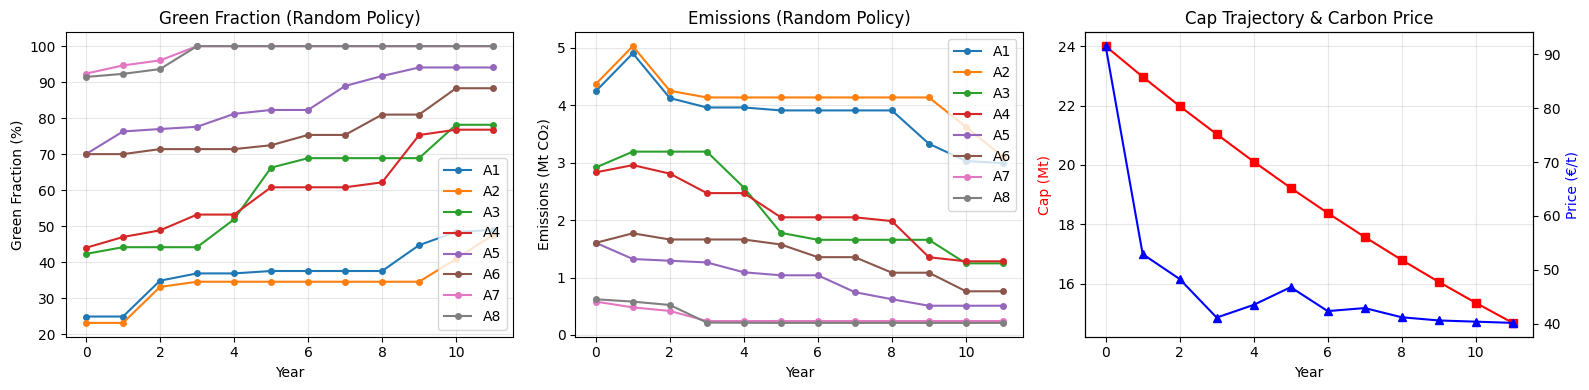

In [8]:
# Plot: Green fraction evolution (random policy)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Green fracs
ax = axes[0]
for i in range(n_agents):
    ax.plot(df['year'], df[f'green_A{i+1}'] * 100, label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Green Fraction (%)')
ax.set_title('Green Fraction (Random Policy)')
ax.legend()
ax.grid(True, alpha=0.3)

# Emissions
ax = axes[1]
for i in range(n_agents):
    ax.plot(df['year'], df[f'emissions_A{i+1}'], label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Emissions (Mt CO₂)')
ax.set_title('Emissions (Random Policy)')
ax.legend()
ax.grid(True, alpha=0.3)

# Cap & Price
ax = axes[2]
ax.plot(df['year'], df['cap'], label='Cap (Mt)', marker='s', color='red')
ax2 = ax.twinx()
ax2.plot(df['year'], df['price'], label='Price (€/t)', marker='^', color='blue')
ax.set_xlabel('Year')
ax.set_ylabel('Cap (Mt)', color='red')
ax2.set_ylabel('Price (€/t)', color='blue')
ax.set_title('Cap Trajectory & Carbon Price')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Train PPO Agents (Short Run)

In [9]:
import copy
from scripts.train import train_one_seed

# Override for quick Colab run (reduce episodes)
train_config = copy.deepcopy(config)
train_config['simulation']['n_episodes'] = 1500
train_config['logging']['log_interval'] = 49
train_config['logging']['save_interval'] = 100

# IPPO: independent critics (better for competitive auction setting)
train_config['ppo']['centralized_critic'] = False

# Reward fixes: stationary shaping + rebalanced magnitudes
train_config['reward']['shaping_weight_floor'] = 1.0    # constant (no decay)
train_config['reward']['shaping_beta'] = 4.0             # was 10.0
train_config['reward']['shaping_gamma'] = 0.5            # was 1.0
train_config['reward']['shaping_lockin_penalty'] = 1.0   # was 2.0
train_config['reward']['shaping_trading_weight'] = 0.3   # was 0.5
train_config['reward']['shaping_coverage_weight'] = 0.8  # was 2.0
# Activate emissions intensity signal (lower floors)
train_config['reward']['green_floor_fossil'] = [0.40, 0.40, 0.30, 0.30, 0.10, 0.10, 0.00, 0.00]

# ── P1: Anti-convergence fixes ──
train_config['ppo']['entropy_coef_final'] = 0.015        # was 0.005 — keep meaningful exploration
train_config['ppo']['log_std_min'] = -1.5                # was -2.0 — prevent over-narrow policies
train_config['ppo']['kl_anchor_decay_episodes'] = 5000   # was 2000 — hold agents near heuristic longer
train_config['diagnostics'] = train_config.get('diagnostics', {})
train_config['diagnostics']['stuck_boost_window'] = 500  # boost entropy after 500 stuck episodes
train_config['diagnostics']['stuck_boost_coef'] = 0.025  # boosted entropy (above initial 0.02)

# ── P2: Carry-forward cap + Curriculum + Reduced penalty multiplier ──
train_config['penalty']['non_compliance_multiplier'] = 1.0   # was 1.5; CF already adds future cost
train_config['penalty']['carry_forward_cap'] = 2.0           # cap CF at 2x base emissions
train_config['curriculum'] = {
    'enabled': True,
    'start_years': 4,        # begin with 4-year episodes
    'ramp_episodes': 3000,   # ramp to full 12 years over 3000 episodes
}

# ── P3: Clipped Gaussian + Epsilon-greedy (code already patched above) ──
train_config['exploration'] = {
    'epsilon_start': 0.15,       # 15% random actions early on
    'epsilon_final': 0.02,       # 2% residual exploration
    'epsilon_decay_episodes': 5000,  # linear decay
}

train_one_seed(train_config, seed=42)



Training — seed 42, 8 agents, IPPO (independent critic), two-phase
v5.0: MAC switching | Electricity revenue | Carry-forward | CF-cap=2.0×
Clipped Gaussian (no tanh) + P1-P8 active | Curriculum 4→12yr | ε-greedy 15%→2%

──────────────────────────────────────────────────────────────────────────────────
TRAINING CONSOLE — COLUMN GUIDE
──────────────────────────────────────────────────────────────────────────────────
Market header  (printed every log_interval episodes)
  price X→Y (peak Z) : ETS clearing price yr-0 → yr-N and peak  (€/t)
  cap                : Cap (Mt) in the final year
  TNAC               : Total allowances in circulation, final year
  sec_price/vol/match: Secondary market stats
  entropy/shaping    : PPO entropy coef & green-shaping weight
  [ENT-DECAY]        : Entropy decay triggered
  [cyc=Ax]           : Active agent (soft cycling)

Per-agent columns
  Green(0→N)  : Green fraction trajectory
  ΔGreen      : Net green change (pp)
  AvgEmiss    : Mean emissions (Mt)

## 6. Analyze Training Results

In [10]:
# Load training logs
ep_df = pd.read_csv('results/training_log_s42.csv')
yr_df = pd.read_csv('results/year_log_s42.csv')

print(f'Training episodes: {len(ep_df)}')
print(f'Year-level records: {len(yr_df)}')
ep_df.tail()

Training episodes: 1500
Year-level records: 8998


,episode,clearing_price_last,cap_last,entropy_coef,shaping_weight,entropy_decay_triggered,active_agent,epsilon,reward_A1,green_frac_A1,...,total_cancels_A7,total_holding_cost_A7,total_mac_reduction_A7,mean_alloc_A8,mean_shock_A8,max_shock_A8,mean_cf_shock_A8,total_cancels_A8,total_holding_cost_A8,total_mac_reduction_A8
1495,1495,40.0,17.570278,0.015,1.0,1,7,0.1111,-3.2894,0.3623,...,0,0.1983,0.0,0.2764,0.0,0.0,0.0,0,0.0975,0.0
1496,1496,40.0,17.570278,0.015,1.0,1,0,0.1111,-0.0058,0.3869,...,0,0.0288,0.0,0.2509,0.0,0.0,0.0,0,0.0530,0.0
1497,1497,40.0,17.570278,0.015,1.0,1,1,0.1111,-1.6322,0.2466,...,0,0.1969,0.0,0.3484,0.0,0.0,0.0,0,0.0682,0.0
1498,1498,40.0,17.570278,0.015,1.0,1,2,0.1111,-4.5727,0.2236,...,0,0.0812,0.0,0.2091,0.0,0.0,0.0,0,0.1633,0.0
1499,1499,40.0,17.570278,0.015,1.0,1,3,0.1110,-0.2036,0.3022,...,0,0.1235,0.0,0.3429,0.0,0.0,0.0,0,0.0723,0.0


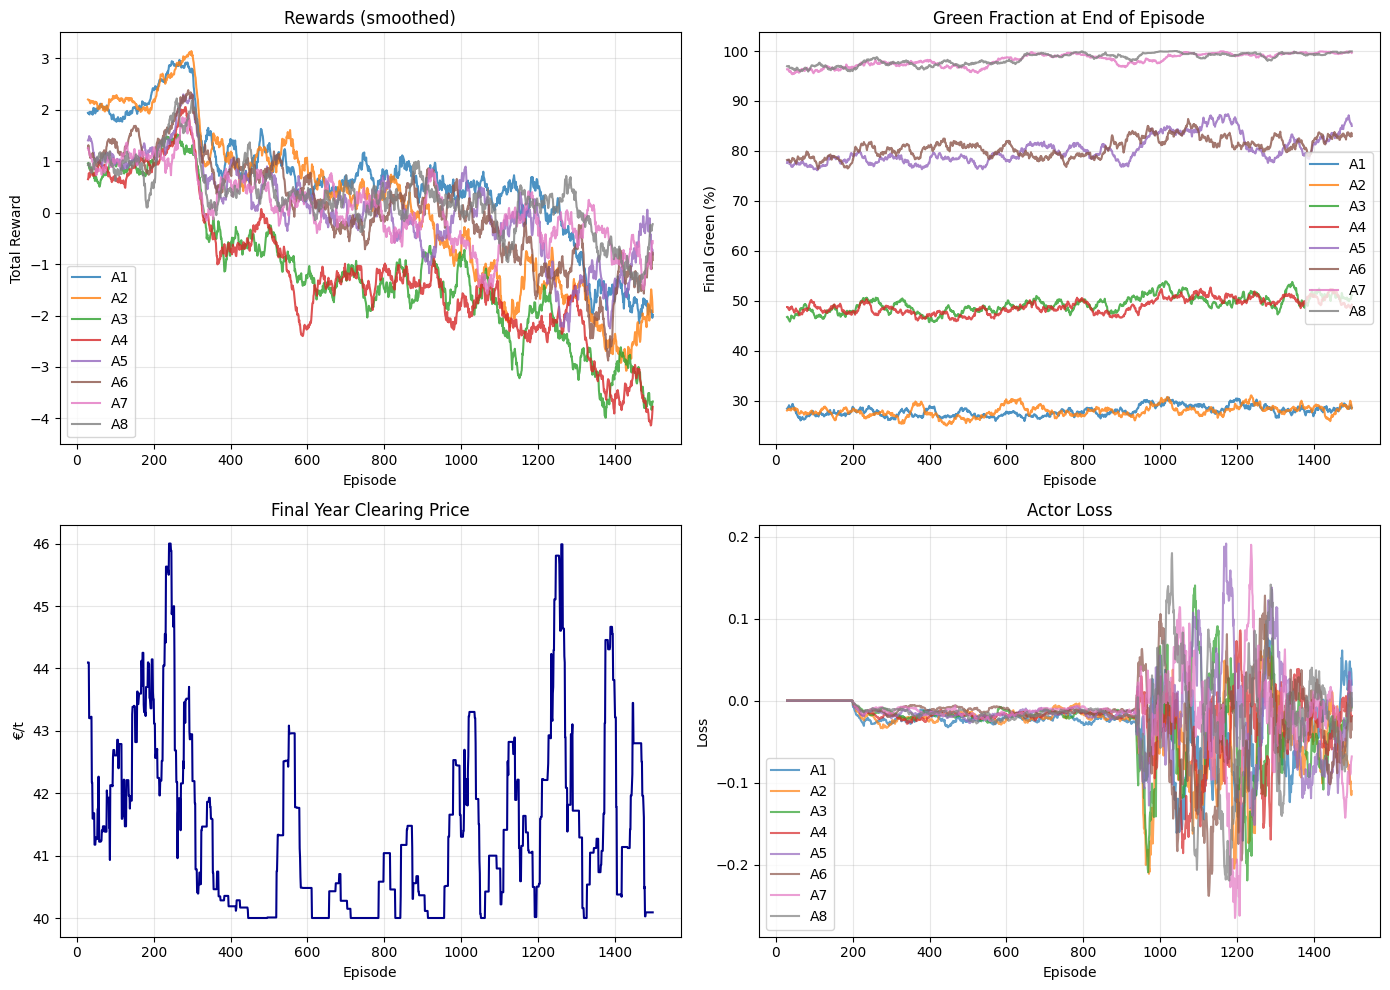

In [11]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
n_agents = config['companies']['n_agents']
window = max(1, len(ep_df) // 50)  # smoothing window

# 1. Rewards
ax = axes[0, 0]
for i in range(n_agents):
    col = f'reward_A{i+1}'
    ax.plot(ep_df['episode'], ep_df[col].rolling(window).mean(), label=f'A{i+1}', alpha=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('Rewards (smoothed)')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Green fractions
ax = axes[0, 1]
for i in range(n_agents):
    col = f'green_frac_A{i+1}'
    ax.plot(ep_df['episode'], ep_df[col].rolling(window).mean() * 100, label=f'A{i+1}', alpha=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel('Final Green (%)')
ax.set_title('Green Fraction at End of Episode')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Clearing price
ax = axes[1, 0]
ax.plot(ep_df['episode'], ep_df['clearing_price_last'].rolling(window).mean(), color='darkblue')
ax.set_xlabel('Episode')
ax.set_ylabel('€/t')
ax.set_title('Final Year Clearing Price')
ax.grid(True, alpha=0.3)

# 4. Actor loss
ax = axes[1, 1]
for i in range(n_agents):
    col = f'actor_loss_A{i+1}'
    ax.plot(ep_df['episode'], ep_df[col].rolling(window).mean(), label=f'A{i+1}', alpha=0.7)
ax.set_xlabel('Episode')
ax.set_ylabel('Loss')
ax.set_title('Actor Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

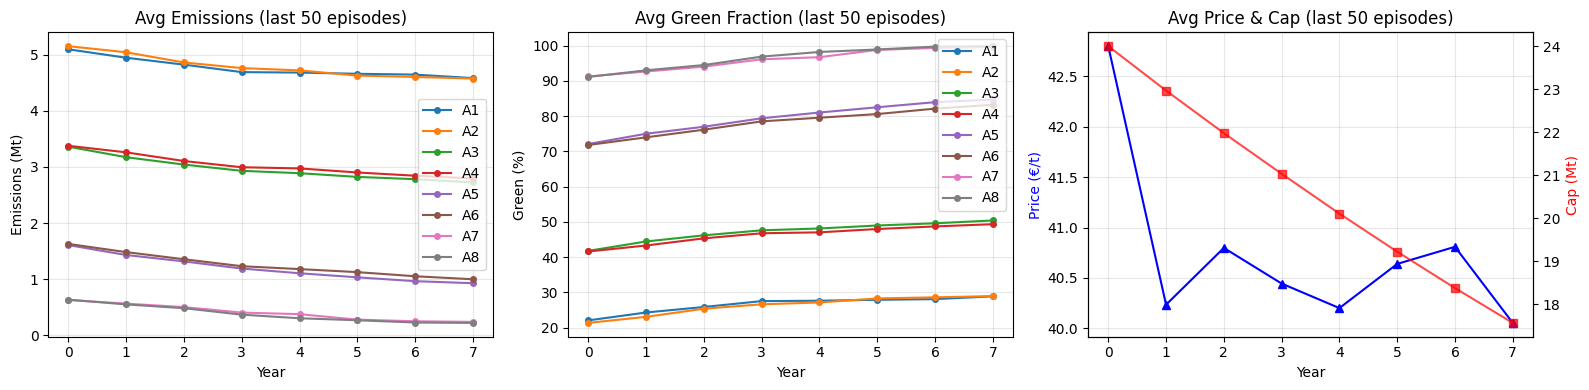

In [12]:
# Year-level analysis: last 50 episodes
last_eps = yr_df['episode'].unique()[-50:]
recent = yr_df[yr_df['episode'].isin(last_eps)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Emissions by year (averaged over recent episodes)
ax = axes[0]
for i in range(n_agents):
    avg = recent.groupby('year')[f'emissions_A{i+1}'].mean()
    ax.plot(avg.index, avg.values, label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Emissions (Mt)')
ax.set_title('Avg Emissions (last 50 episodes)')
ax.legend()
ax.grid(True, alpha=0.3)

# Green frac by year
ax = axes[1]
for i in range(n_agents):
    avg = recent.groupby('year')[f'green_frac_A{i+1}'].mean()
    ax.plot(avg.index, avg.values * 100, label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Green (%)')
ax.set_title('Avg Green Fraction (last 50 episodes)')
ax.legend()
ax.grid(True, alpha=0.3)

# Carbon price trajectory
ax = axes[2]
avg_price = recent.groupby('year')['clearing_price'].mean()
avg_cap = recent.groupby('year')['cap'].mean()
ax.plot(avg_price.index, avg_price.values, label='Clearing Price', marker='^', color='blue')
ax2 = ax.twinx()
ax2.plot(avg_cap.index, avg_cap.values, label='Cap', marker='s', color='red', alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Price (€/t)', color='blue')
ax2.set_ylabel('Cap (Mt)', color='red')
ax.set_title('Avg Price & Cap (last 50 episodes)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6b. P5–P8 & MAC Stochastic Deviation Analysis

Visualise the **random noise** and **abatement mechanisms** across training:
- **P5** — Emission demand shocks (ε ~ correlated normal, σ=7%)
- **P6** — Green capacity-factor noise + project cancellations
- **P8** — Banking holding costs (penalty for excess allowance hoarding)
- **MAC** — Fuel-switching abatement (coal→gas dispatch when carbon price > €65/t)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


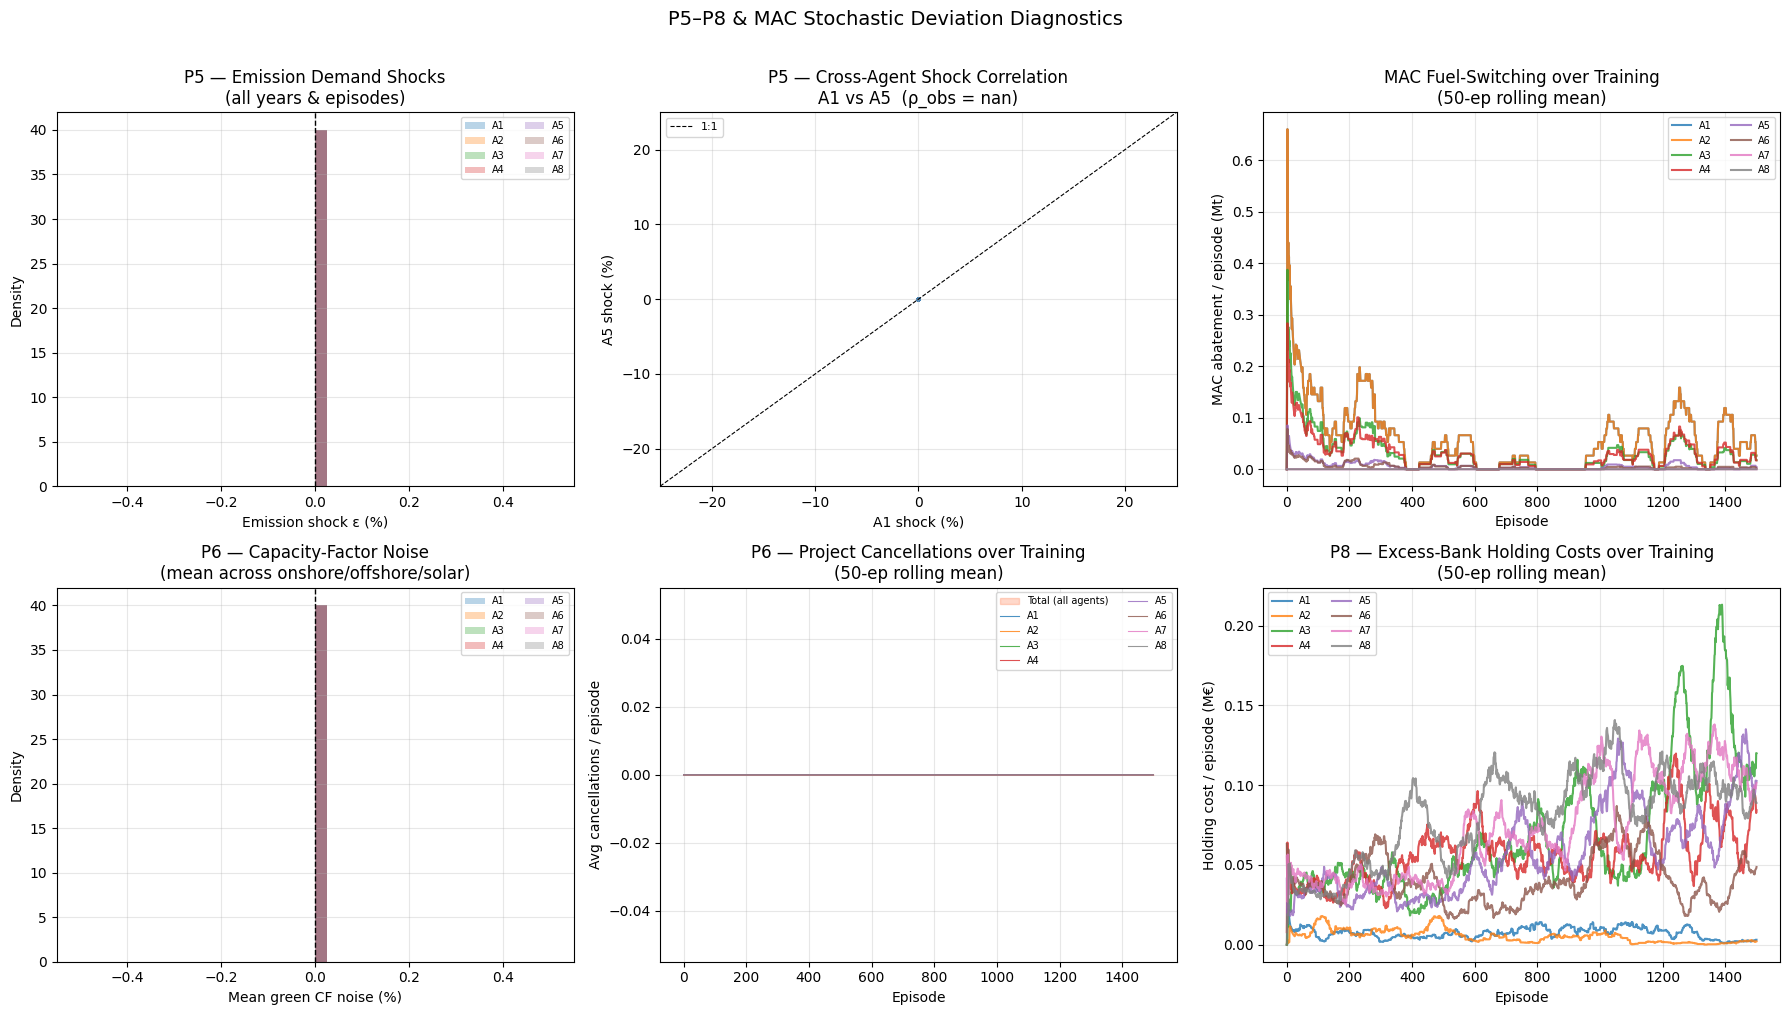


─── P5/P6/P8/MAC deviation summary (all training data) ───
    ε_mean (%)  ε_std (%)  CF_noise_std (%)  cancels_total  holdcost_sum (M€)  mac_total (Mt)
A1         0.0        0.0               0.0            0.0              10.78           84.47
A2         0.0        0.0               0.0            0.0               7.92           84.48
A3         0.0        0.0               0.0            0.0             105.36           42.92
A4         0.0        0.0               0.0            0.0              85.79           41.11
A5         0.0        0.0               0.0            0.0              87.29            8.35
A6         0.0        0.0               0.0            0.0              60.38            6.44
A7         0.0        0.0               0.0            0.0             109.69            0.00
A8         0.0        0.0               0.0            0.0             121.82            0.00


In [13]:
# ── P5/P6/P8 stochastic deviation analysis ─────────────────────────────────
yr_df = pd.read_csv('results/year_log_s42.csv')
n_agents = config['companies']['n_agents']
tech_names = config['technologies']['names']

# Check which deviation columns exist
shock_cols    = [f'emission_shock_A{i+1}' for i in range(n_agents)]
cf_cols       = [f'cf_shock_A{i+1}'       for i in range(n_agents)]
cancel_cols   = [f'cancellation_A{i+1}'   for i in range(n_agents)]
hcost_cols    = [f'holding_cost_A{i+1}'   for i in range(n_agents)]
mac_cols      = [f'mac_reduction_A{i+1}'  for i in range(n_agents)]

has_deviations = all(c in yr_df.columns for c in shock_cols)
has_mac = all(c in yr_df.columns for c in mac_cols)

cmap = plt.get_cmap('tab10')
agent_colors = [cmap(i % 10) for i in range(n_agents)]
leg_ncol = max(1, n_agents // 4)
bar_alpha = max(0.25, 0.55 - n_agents * 0.03)  # reduce opacity with more agents

if not has_deviations:
    print('Deviation columns not found — re-run training with the updated train.py')
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # ── 1. P5 emission shock distribution (all agents, all years) ────────────
    ax = axes[0, 0]
    for i in range(n_agents):
        vals = yr_df[shock_cols[i]] * 100
        ax.hist(vals, bins=40, alpha=bar_alpha, label=f'A{i+1}',
                density=True, color=agent_colors[i])
    ax.axvline(0, color='k', lw=1, ls='--')
    ax.set_xlabel('Emission shock ε (%)')
    ax.set_ylabel('Density')
    ax.set_title('P5 — Emission Demand Shocks\n(all years & episodes)')
    ax.legend(fontsize=7, ncol=leg_ncol)
    ax.grid(True, alpha=0.3)

    # ── 2. P5 shock correlation check (A1 vs A(n//2) — spread archetypes) ────
    ax = axes[0, 1]
    idx_a, idx_b = 0, max(1, n_agents // 2)
    ax.scatter(yr_df[shock_cols[idx_a]] * 100, yr_df[shock_cols[idx_b]] * 100,
               alpha=0.15, s=4, color='steelblue')
    lims = [-25, 25]
    ax.plot(lims, lims, 'k--', lw=0.8, label='1:1')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f'A{idx_a+1} shock (%)')
    ax.set_ylabel(f'A{idx_b+1} shock (%)')
    corr = yr_df[shock_cols[idx_a]].corr(yr_df[shock_cols[idx_b]])
    ax.set_title(f'P5 — Cross-Agent Shock Correlation\nA{idx_a+1} vs A{idx_b+1}  (ρ_obs = {corr:.2f})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── 3. MAC fuel-switching over training ──────────────────────────────────
    ax = axes[0, 2]
    if has_mac:
        ep_mac = (
            yr_df.groupby('episode')[[*mac_cols]]
            .sum()
            .rolling(50, min_periods=1)
            .mean()
        )
        for i in range(n_agents):
            ax.plot(ep_mac.index, ep_mac[mac_cols[i]],
                    label=f'A{i+1}', alpha=0.8, color=agent_colors[i])
        ax.set_xlabel('Episode')
        ax.set_ylabel('MAC abatement / episode (Mt)')
        ax.set_title('MAC Fuel-Switching over Training\n(50-ep rolling mean)')
        ax.legend(fontsize=7, ncol=leg_ncol)
    else:
        # Fallback: P5 shock volatility
        ep_shock_std = (
            yr_df.groupby('episode')[[*shock_cols]]
            .std()
            .rolling(50, min_periods=1)
            .mean()
        )
        for i in range(n_agents):
            ax.plot(ep_shock_std.index, ep_shock_std[shock_cols[i]] * 100,
                    label=f'A{i+1}', alpha=0.8, color=agent_colors[i])
        ax.axhline(7.0, color='k', ls='--', lw=0.8, label='σ_demand=7%')
        ax.set_xlabel('Episode')
        ax.set_ylabel('Within-episode shock std (%)')
        ax.set_title('P5 — Emission Shock Volatility over Training')
        ax.legend(fontsize=7, ncol=leg_ncol)
    ax.grid(True, alpha=0.3)

    # ── 4. P6 CF noise distribution (green techs averaged) ───────────────────
    ax = axes[1, 0]
    for i in range(n_agents):
        vals = yr_df[cf_cols[i]] * 100
        ax.hist(vals, bins=40, alpha=bar_alpha, label=f'A{i+1}',
                density=True, color=agent_colors[i])
    ax.axvline(0, color='k', lw=1, ls='--')
    ax.set_xlabel('Mean green CF noise (%)')
    ax.set_ylabel('Density')
    ax.set_title('P6 — Capacity-Factor Noise\n(mean across onshore/offshore/solar)')
    ax.legend(fontsize=7, ncol=leg_ncol)
    ax.grid(True, alpha=0.3)

    # ── 5. P6 project cancellations over training ─────────────────────────────
    ax = axes[1, 1]
    ep_cancels = (
        yr_df.groupby('episode')[[*cancel_cols]]
        .sum()
        .rolling(50, min_periods=1)
        .mean()
    )
    ep_cancels['total'] = ep_cancels[cancel_cols].sum(axis=1)
    ax.fill_between(ep_cancels.index, ep_cancels['total'],
                    alpha=0.3, color='coral', label='Total (all agents)')
    for i in range(n_agents):
        ax.plot(ep_cancels.index, ep_cancels[cancel_cols[i]],
                lw=0.8, label=f'A{i+1}', alpha=0.8, color=agent_colors[i])
    ax.set_xlabel('Episode')
    ax.set_ylabel('Avg cancellations / episode')
    ax.set_title('P6 — Project Cancellations over Training\n(50-ep rolling mean)')
    ax.legend(fontsize=7, ncol=leg_ncol)
    ax.grid(True, alpha=0.3)

    # ── 6. P8 holding cost over training ─────────────────────────────────────
    ax = axes[1, 2]
    has_hcost = all(c in yr_df.columns for c in hcost_cols)
    if has_hcost:
        ep_hcost = (
            yr_df.groupby('episode')[[*hcost_cols]]
            .sum()
            .rolling(50, min_periods=1)
            .mean()
        )
        for i in range(n_agents):
            ax.plot(ep_hcost.index, ep_hcost[hcost_cols[i]],
                    label=f'A{i+1}', alpha=0.8, color=agent_colors[i])
        ax.set_xlabel('Episode')
        ax.set_ylabel('Holding cost / episode (M€)')
        ax.set_title('P8 — Excess-Bank Holding Costs over Training\n(50-ep rolling mean)')
        ax.legend(fontsize=7, ncol=leg_ncol)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'holding_cost columns\nnot found in CSV',
                ha='center', va='center', transform=ax.transAxes)

    plt.suptitle('P5–P8 & MAC Stochastic Deviation Diagnostics', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    # Summary statistics table
    print('\n─── P5/P6/P8/MAC deviation summary (all training data) ───')
    summary = {}
    for i in range(n_agents):
        row = {
            'ε_mean (%)':       round(yr_df[shock_cols[i]].mean()  * 100, 3),
            'ε_std (%)':        round(yr_df[shock_cols[i]].std()   * 100, 3),
            'CF_noise_std (%)': round(yr_df[cf_cols[i]].std()      * 100, 3),
            'cancels_total':    int(yr_df[cancel_cols[i]].sum()),
            'holdcost_sum (M€)': round(yr_df[hcost_cols[i]].sum(), 2) if has_hcost else 'n/a',
        }
        if has_mac:
            row['mac_total (Mt)'] = round(yr_df[mac_cols[i]].sum(), 2)
        summary[f'A{i+1}'] = row
    print(pd.DataFrame(summary).T.to_string())


## 6c. Year-by-Year Trajectory Analysis (last N episodes)

Slices the **year_log** to show how behaviour evolves *within* an episode across years 0–9.
Uses the last 100 episodes so the plots represent mature policy behaviour, not early exploration.

Four panels per row:
1. **Allocation vs Emissions** — over-allocation → surplus banking; under-allocation → shortfall risk  
2. **Banking** — bank_start and bank_end per year to see carry-forward dynamics  
3. **Secondary market net** — positive = net seller (revenue), negative = net buyer (cost)  
4. **Compliance surplus / shortfall** — pre-compliance headroom; negative → penalty risk

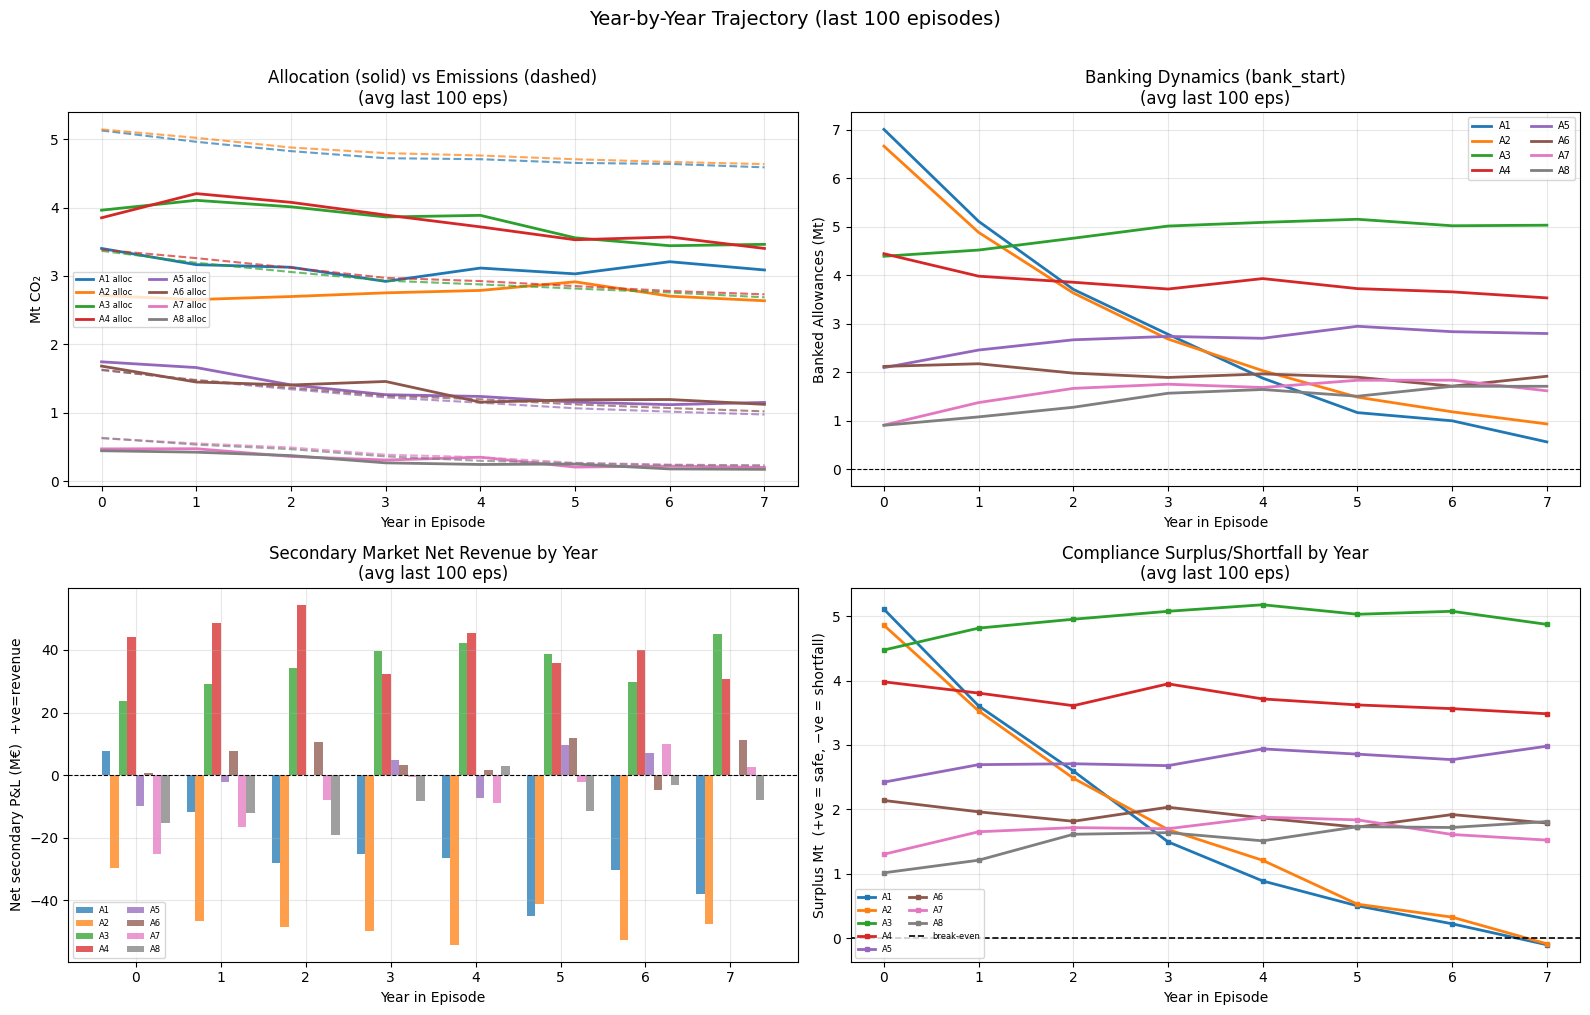


── Average yearly cost breakdown (last 100 eps, all agents combined) ──
      A1_auc(M€)  A1_inv(M€)  A1_pen(M€)  A2_auc(M€)  A2_inv(M€)  A2_pen(M€)  A3_auc(M€)  A3_inv(M€)  A3_pen(M€)  A4_auc(M€)  A4_inv(M€)  A4_pen(M€)  A5_auc(M€)  A5_inv(M€)  A5_pen(M€)  A6_auc(M€)  A6_inv(M€)  A6_pen(M€)  A7_auc(M€)  A7_inv(M€)  A7_pen(M€)  A8_auc(M€)  A8_inv(M€)  A8_pen(M€)
year                                                                                                                                                                                                                                                                                                
0         140.00       91.46        0.66      114.00       65.09        2.77      165.14      156.00        4.88      160.09      139.31        0.39       72.90      198.97        3.81       69.86      198.02        3.95       19.39      202.35        7.41       18.17      244.99        6.70
1         129.33       48.12       11.20      10

In [14]:
# ── 6c: Year-by-year trajectory analysis ──────────────────────────────────
yr_df = pd.read_csv('results/year_log_s42.csv')
n_agents = config['companies']['n_agents']

N_LAST = 100  # episodes to average over
last_eps = yr_df['episode'].unique()[-N_LAST:]
recent = yr_df[yr_df['episode'].isin(last_eps)].copy()

# Check which new columns are present
has_bank_end   = 'bank_end_A1'            in recent.columns
has_sec_net    = 'secondary_net_A1'       in recent.columns
has_surplus    = 'compliance_surplus_A1'  in recent.columns
has_auc_cost   = 'auction_cost_A1'        in recent.columns

cmap = plt.get_cmap('tab10')
agent_colors = [cmap(i) for i in range(n_agents)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Panel 1: Allocation vs Emissions ──────────────────────────────────────
ax = axes[0, 0]
for i in range(n_agents):
    alloc_avg = recent.groupby('year')[f'alloc_A{i+1}'].mean()
    emiss_avg = recent.groupby('year')[f'emissions_A{i+1}'].mean()
    ax.plot(alloc_avg.index, alloc_avg.values,
            color=agent_colors[i], lw=2, label=f'A{i+1} alloc')
    ax.plot(emiss_avg.index, emiss_avg.values,
            color=agent_colors[i], lw=1.5, ls='--', alpha=0.7)
ax.set_xlabel('Year in Episode')
ax.set_ylabel('Mt CO₂')
ax.set_title(f'Allocation (solid) vs Emissions (dashed)\n(avg last {N_LAST} eps)')
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

# ── Panel 2: Banking dynamics (bank_start and bank_end) ────────────────────
ax = axes[0, 1]
for i in range(n_agents):
    bs = recent.groupby('year')[f'bank_start_A{i+1}'].mean()
    ax.plot(bs.index, bs.values, color=agent_colors[i], lw=2,
            label=f'A{i+1}')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Year in Episode')
ax.set_ylabel('Banked Allowances (Mt)')
ax.set_title(f'Banking Dynamics (bank_start)\n(avg last {N_LAST} eps)')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# ── Panel 3: Secondary market net (positive = net revenue) ────────────────
ax = axes[1, 0]
if has_sec_net:
    bar_width = 0.8 / n_agents
    for i in range(n_agents):
        avg = recent.groupby('year')[f'secondary_net_A{i+1}'].mean()
        ax.bar(avg.index + i * bar_width - 0.4 + bar_width/2, avg.values,
               width=bar_width, color=agent_colors[i], alpha=0.75, label=f'A{i+1}')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Year in Episode')
    ax.set_ylabel('Net secondary P&L (M€)  +ve=revenue')
    ax.set_title(f'Secondary Market Net Revenue by Year\n(avg last {N_LAST} eps)')
    ax.legend(fontsize=6, ncol=2)
else:
    for i in range(n_agents):
        avg = recent.groupby('year')[f'trade_cost_A{i+1}'].mean()
        ax.plot(avg.index, -avg.values, color=agent_colors[i], lw=1.5,
                label=f'A{i+1}', marker='o', markersize=3)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Year in Episode')
    ax.set_ylabel('−trade_cost (M€)  +ve=revenue')
    ax.set_title(f'Secondary Net (from trade_cost, last {N_LAST} eps)')
    ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

# ── Panel 4: Compliance surplus / shortfall ───────────────────────────────
ax = axes[1, 1]
if has_surplus:
    for i in range(n_agents):
        avg = recent.groupby('year')[f'compliance_surplus_A{i+1}'].mean()
        ax.plot(avg.index, avg.values, color=agent_colors[i], lw=2,
                marker='s', markersize=3, label=f'A{i+1}')
    ax.axhline(0, color='k', lw=1.2, ls='--', label='break-even')
else:
    for i in range(n_agents):
        sf = recent.groupby('year')[f'shortfall_A{i+1}'].mean()
        ax.plot(sf.index, -sf.values, color=agent_colors[i], lw=2,
                marker='s', markersize=3, label=f'A{i+1}')
    ax.axhline(0, color='k', lw=1.2, ls='--')
ax.set_xlabel('Year in Episode')
ax.set_ylabel('Surplus Mt  (+ve = safe, −ve = shortfall)')
ax.set_title(f'Compliance Surplus/Shortfall by Year\n(avg last {N_LAST} eps)')
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

plt.suptitle(f'Year-by-Year Trajectory (last {N_LAST} episodes)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Cost breakdown summary per year (if auction_cost logged) ──────────────
if has_auc_cost:
    print(f'\n── Average yearly cost breakdown (last {N_LAST} eps, all agents combined) ──')
    cols_show = {}
    for i in range(n_agents):
        cols_show[f'A{i+1}_auc(M€)'] = recent.groupby('year')[f'auction_cost_A{i+1}'].mean()
        cols_show[f'A{i+1}_inv(M€)'] = recent.groupby('year')[f'invest_cost_A{i+1}'].mean()
        cols_show[f'A{i+1}_pen(M€)'] = recent.groupby('year')[f'penalty_A{i+1}'].mean()
    print(pd.DataFrame(cols_show).round(2).to_string())


## 6d. Episode Consistency & Variance (ribbon plots)

Shows **mean ± 1 std** bands over the last 100 episodes for key year-level signals.
Wide bands → high variance / unstable policy. Narrow bands → consistent behaviour.

Includes a **price ribbon** (year 0→9 trajectory) and per-agent **green fraction trajectory**.

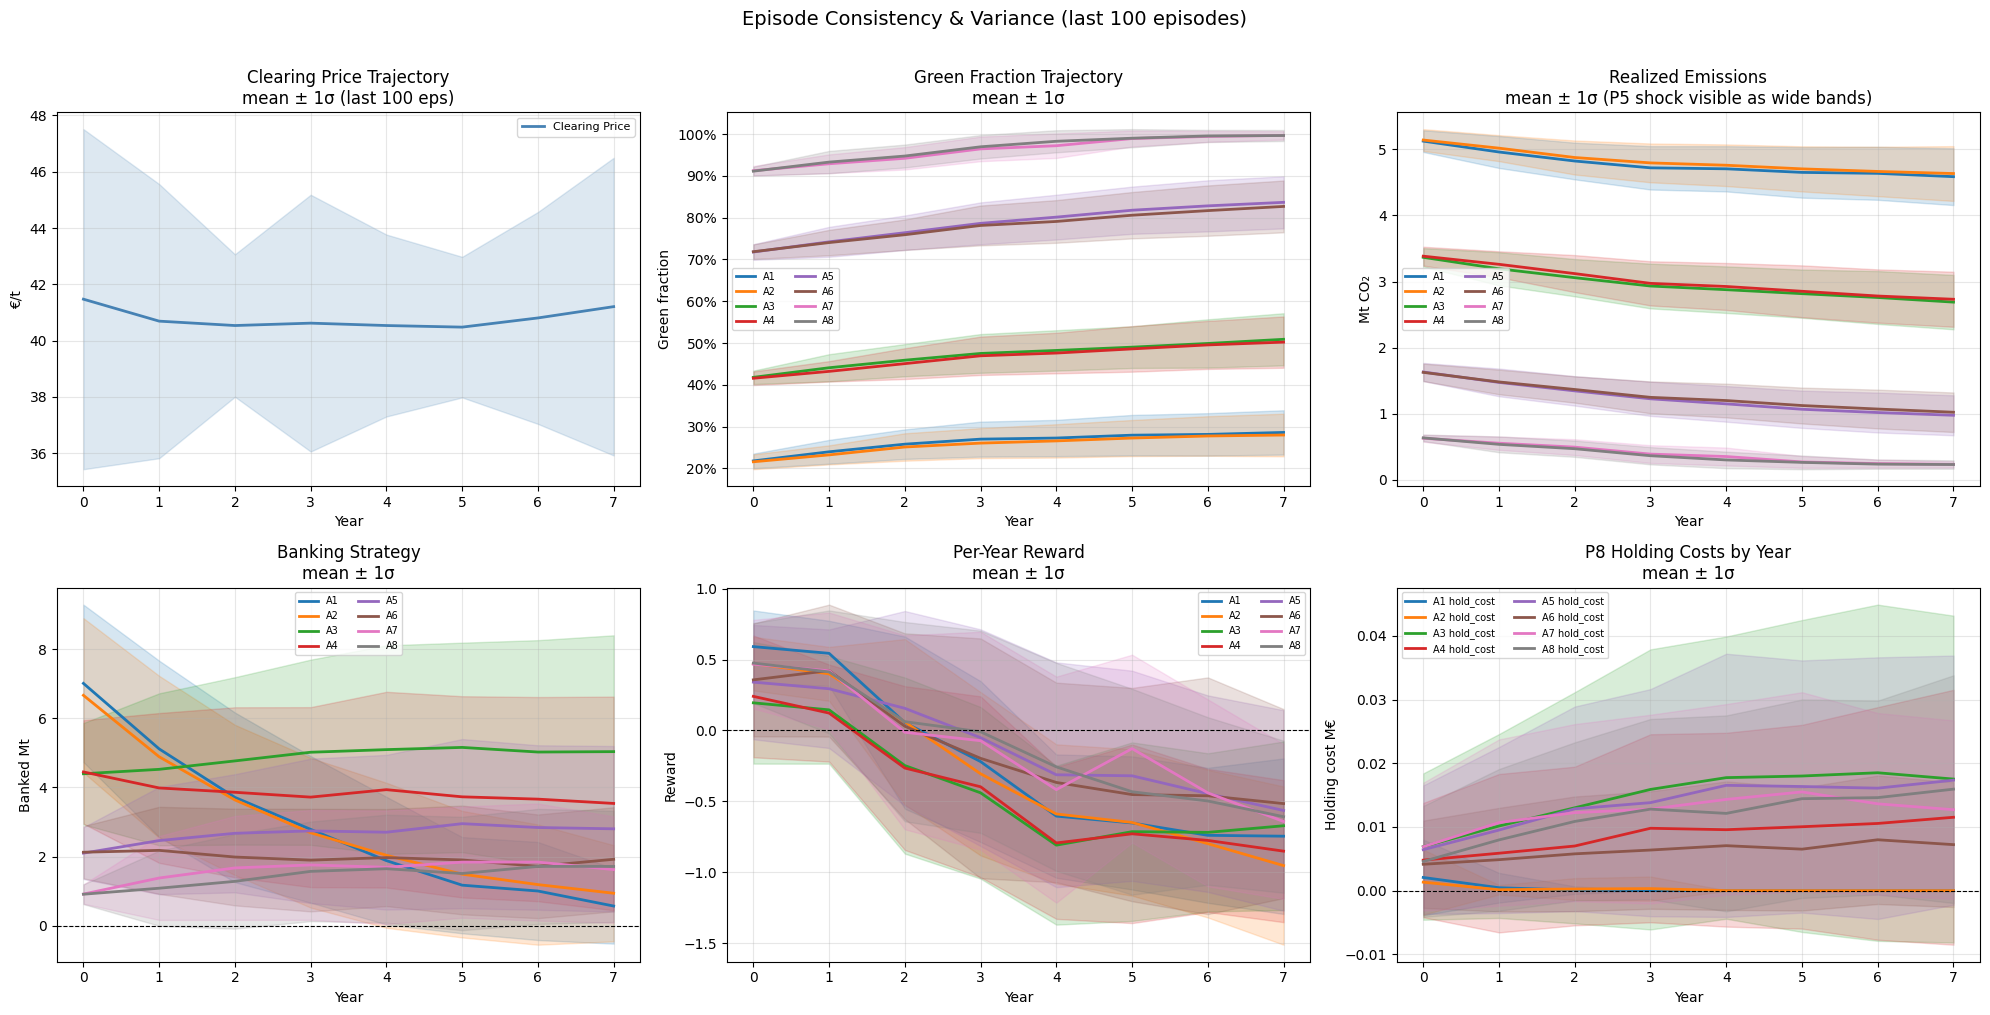


── Year-level variance summary (std across 100 episodes, mean over years) ──
    price_std (€/t)  green_frac_std  emissions_std(Mt)  bank_std(Mt)  reward_std
A1              4.1          0.0398              0.321         1.895      0.4486
A2              4.1          0.0363              0.295         1.997      0.4532
A3              4.1          0.0440              0.317         2.678      0.5471
A4              4.1          0.0431              0.315         2.565      0.5197
A5              4.1          0.0474              0.248         1.946      0.6508
A6              4.1          0.0451              0.235         1.361      0.6652
A7              4.1          0.0201              0.093         1.384      0.6051
A8              4.1          0.0211              0.098         1.333      0.5898


In [15]:
# ── 6d: Episode consistency – ribbon plots (mean ± 1σ over last 100 episodes) ──
yr_df = pd.read_csv('results/year_log_s42.csv')
n_agents = config['companies']['n_agents']

N_LAST = 100
last_eps = yr_df['episode'].unique()[-N_LAST:]
recent = yr_df[yr_df['episode'].isin(last_eps)].copy()
years  = sorted(recent['year'].unique())

def ribbon(ax, grp, col, color, label):
    """Plot mean ± 1 std ribbon for `col` grouped by year."""
    mu  = grp[col].mean()
    std = grp[col].std().fillna(0)
    ax.plot(mu.index, mu.values, color=color, lw=2, label=label)
    ax.fill_between(mu.index, mu - std, mu + std,
                    color=color, alpha=0.18)

grp = recent.groupby('year')
# Use a colormap that handles 8+ agents
cmap = plt.get_cmap('tab10')
agent_colors = [cmap(i) for i in range(n_agents)]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# ── 1. Clearing price trajectory ──────────────────────────────────────────
ax = axes[0, 0]
ribbon(ax, grp, 'clearing_price', 'steelblue', 'Clearing Price')
ax.set_xlabel('Year'); ax.set_ylabel('€/t')
ax.set_title('Clearing Price Trajectory\nmean ± 1σ (last 100 eps)')
ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

# ── 2. Green fraction per agent ───────────────────────────────────────────
ax = axes[0, 1]
for i in range(n_agents):
    ribbon(ax, grp, f'green_frac_A{i+1}', agent_colors[i], f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Green fraction')
ax.set_title('Green Fraction Trajectory\nmean ± 1σ')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=2)

# ── 3. Emissions per agent ────────────────────────────────────────────────
ax = axes[0, 2]
for i in range(n_agents):
    ribbon(ax, grp, f'emissions_A{i+1}', agent_colors[i], f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂')
ax.set_title('Realized Emissions\nmean ± 1σ (P5 shock visible as wide bands)')
ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=2)

# ── 4. Banking (bank_start) per agent ─────────────────────────────────────
ax = axes[1, 0]
for i in range(n_agents):
    ribbon(ax, grp, f'bank_start_A{i+1}', agent_colors[i], f'A{i+1}')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Year'); ax.set_ylabel('Banked Mt')
ax.set_title('Banking Strategy\nmean ± 1σ')
ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=2)

# ── 5. Reward per agent ───────────────────────────────────────────────────
ax = axes[1, 1]
for i in range(n_agents):
    ribbon(ax, grp, f'reward_A{i+1}', agent_colors[i], f'A{i+1}')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Year'); ax.set_ylabel('Reward')
ax.set_title('Per-Year Reward\nmean ± 1σ')
ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=2)

# ── 6. P8 holding cost (if logged) / shortfall ────────────────────────────
ax = axes[1, 2]
has_hcost = 'holding_cost_A1' in recent.columns
if has_hcost:
    for i in range(n_agents):
        ribbon(ax, grp, f'holding_cost_A{i+1}', agent_colors[i], f'A{i+1} hold_cost')
    ax.set_ylabel('Holding cost M€')
    ax.set_title('P8 Holding Costs by Year\nmean ± 1σ')
else:
    for i in range(n_agents):
        ribbon(ax, grp, f'shortfall_A{i+1}', agent_colors[i], f'A{i+1}')
    ax.set_ylabel('Shortfall Mt')
    ax.set_title('Shortfall by Year\nmean ± 1σ')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Year'); ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=2)

plt.suptitle(f'Episode Consistency & Variance (last {N_LAST} episodes)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Variance summary table ────────────────────────────────────────────────
print(f'\n── Year-level variance summary (std across {N_LAST} episodes, mean over years) ──')
var_summary = {}
for i in range(n_agents):
    var_summary[f'A{i+1}'] = {
        'price_std (€/t)':   round(recent.groupby('year')['clearing_price'].std().mean(), 2),
        'green_frac_std':    round(recent.groupby('year')[f'green_frac_A{i+1}'].std().mean(), 4),
        'emissions_std(Mt)': round(recent.groupby('year')[f'emissions_A{i+1}'].std().mean(), 3),
        'bank_std(Mt)':      round(recent.groupby('year')[f'bank_start_A{i+1}'].std().mean(), 3),
        'reward_std':        round(recent.groupby('year')[f'reward_A{i+1}'].std().mean(), 4),
    }
print(pd.DataFrame(var_summary).T.to_string())


## 7. Evaluate Best Agents (Deterministic)

In [16]:
from scripts.train import build_agents

# Load best checkpoints
eval_env = ETSEnvironment(config, seed=0)
eval_agents = build_agents(eval_env, config, seed=0)
n_agents = config['companies']['n_agents']

ckpt_dir = 'results/checkpoints_s42'
for i, agent in enumerate(eval_agents):
    ckpt_path = os.path.join(ckpt_dir, f'agent_{i}_best.pt')
    if os.path.exists(ckpt_path):
        agent.load(ckpt_path)
        print(f'Loaded agent {i}')
    else:
        print(f'No checkpoint for agent {i} — using untrained policy')

# Run deterministic evaluation
obs1, _ = eval_env.reset(seed=0)
eval_data = []

for year in range(config['simulation']['n_years']):
    auction_actions = np.zeros((n_agents, 6), dtype=np.float32)
    for i in range(n_agents):
        action, _, _ = eval_agents[i].select_auction_action(obs1[i], deterministic=True)
        auction_actions[i] = action
    obs2, _ = eval_env.step_auction(auction_actions)

    secondary_actions = np.zeros((n_agents, 2), dtype=np.float32)
    for i in range(n_agents):
        action, _, _ = eval_agents[i].select_secondary_action(obs2[i], deterministic=True)
        secondary_actions[i] = action

    obs1, rewards, terminated, _, info = eval_env.step_secondary(secondary_actions)
    log = info['year_log']

    row = {'year': year, 'cap': log['cap'], 'price': log['clearing_price']}
    for i in range(n_agents):
        row[f'green_A{i+1}'] = log['green_fracs'][i]
        row[f'emissions_A{i+1}'] = log['emissions'][i]
        for t in range(5):
            row[f'mix_A{i+1}_{tech_names[t]}'] = log['tech_mixes'][i][t]
    eval_data.append(row)
    if terminated:
        break

eval_df = pd.DataFrame(eval_data)
green_cols = ['year', 'cap', 'price'] + [f'green_A{i+1}' for i in range(n_agents)]
print(eval_df[green_cols].to_string(index=False))

Loaded agent 0
Loaded agent 1
Loaded agent 2
Loaded agent 3
Loaded agent 4
Loaded agent 5
Loaded agent 6
Loaded agent 7
 year       cap     price  green_A1  green_A2  green_A3  green_A4  green_A5  green_A6  green_A7  green_A8
    0 24.000000 41.985714  0.225409  0.222264  0.437506  0.439117  0.700000  0.718440  0.900000  0.900000
    1 22.968000 40.000000  0.225409  0.229749  0.437506  0.439117  0.706040  0.718440  0.917404  0.900000
    2 21.980376 40.000000  0.263430  0.229749  0.437506  0.439117  0.725303  0.749830  0.929845  0.925376
    3 21.035220 40.000000  0.263430  0.229749  0.481162  0.456003  0.725303  0.749830  0.947621  0.972933
    4 20.109670 40.000000  0.263430  0.229749  0.493940  0.456003  0.725303  0.756662  0.985604  0.995439
    5 19.224845 40.000000  0.263430  0.229749  0.493940  0.456003  0.725303  0.756662  1.000000  1.000000
    6 18.378952 40.000000  0.263430  0.229749  0.493940  0.456003  0.725303  0.764217  1.000000  1.000000
    7 17.570278 40.000000  0.263

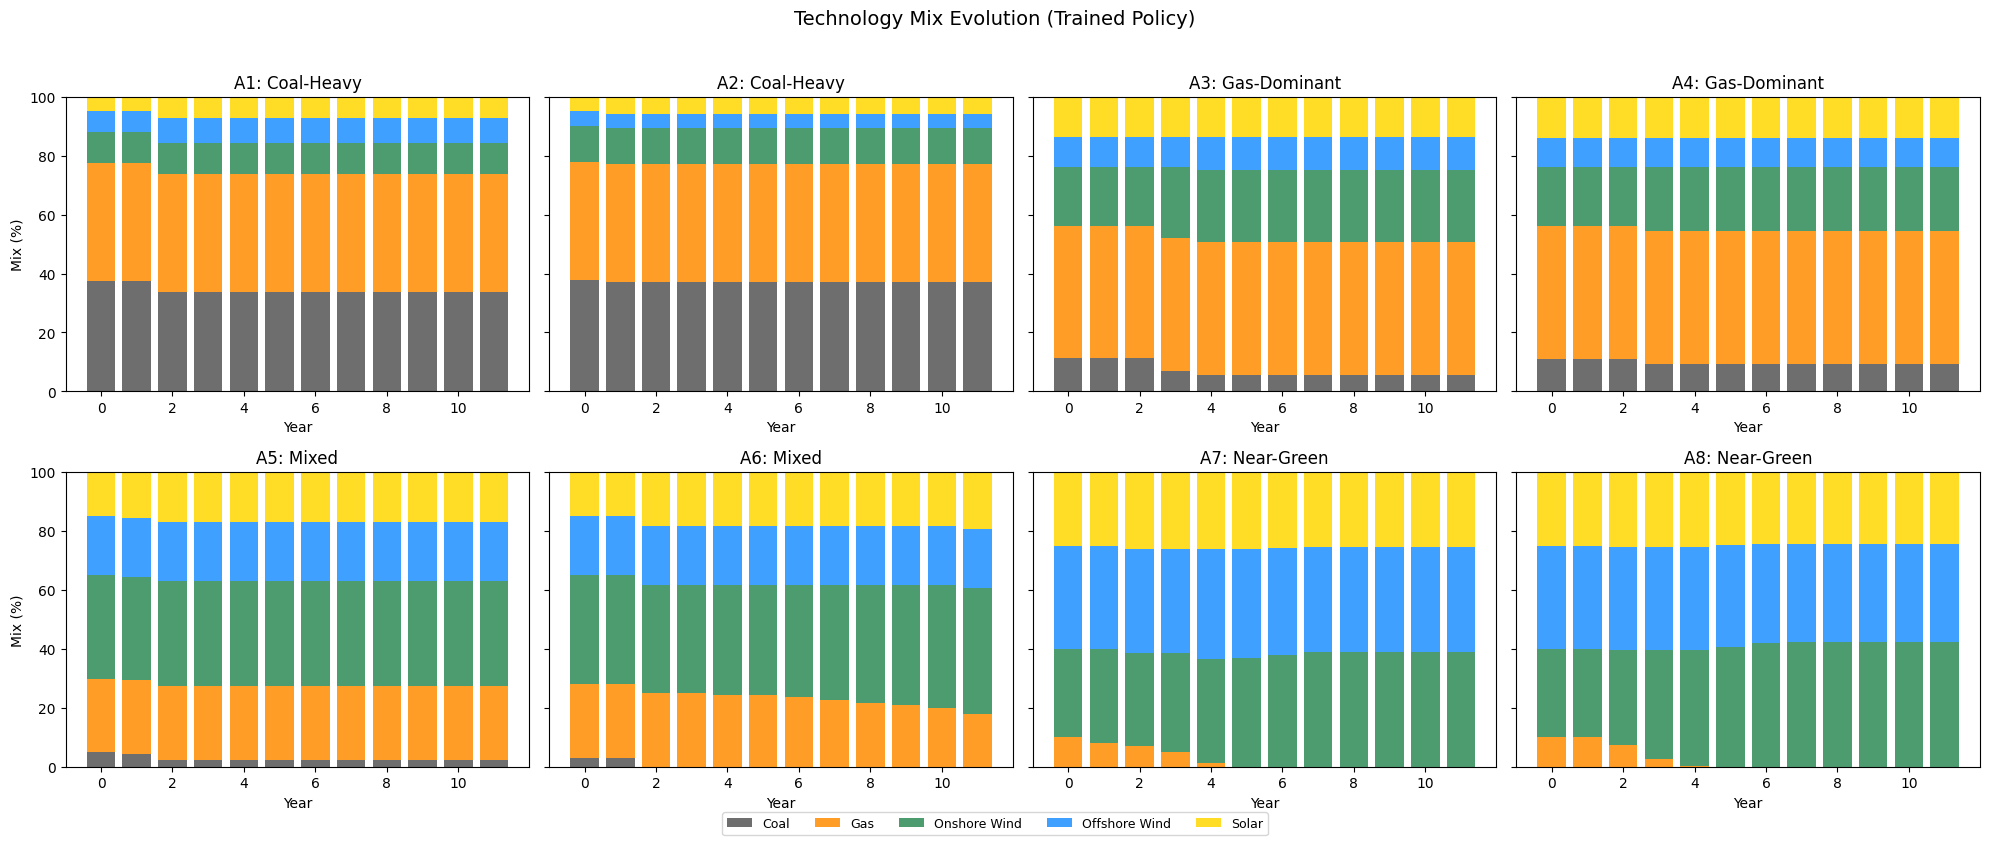

In [17]:
# Technology mix evolution per agent
tech_names = config['technologies']['names']
colors = {'coal': '#555555', 'gas': '#FF8C00', 'onshore_wind': '#2E8B57',
          'offshore_wind': '#1E90FF', 'solar': '#FFD700'}

# Dynamic archetype labels (2 of each for 8 agents)
_base_archetypes = ['Coal-Heavy', 'Gas-Dominant', 'Mixed', 'Near-Green']
archetypes = []
for arch in _base_archetypes:
    count = 0
    for mix in config['companies']['initial_mix']:
        # Match archetype by green fraction
        green = sum(mix[j] for j, g in enumerate(config['technologies']['is_green']) if g)
        if arch == 'Coal-Heavy' and green < 0.25:
            count += 1
        elif arch == 'Gas-Dominant' and 0.25 <= green < 0.55:
            count += 1
        elif arch == 'Mixed' and 0.55 <= green < 0.85:
            count += 1
        elif arch == 'Near-Green' and green >= 0.85:
            count += 1
# Simpler: just assign based on position
archetypes = []
n_per = n_agents // 4
for arch in _base_archetypes:
    for k in range(max(1, n_per)):
        archetypes.append(arch)
# Pad if needed
while len(archetypes) < n_agents:
    archetypes.append(f'Agent {len(archetypes)+1}')

ncols = min(4, n_agents)
nrows = (n_agents + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), sharey=True)
axes = np.atleast_1d(axes).flatten()

for i in range(n_agents):
    ax = axes[i]
    bottom = np.zeros(len(eval_df))
    for t in range(5):
        vals = eval_df[f'mix_A{i+1}_{tech_names[t]}'].values * 100
        ax.bar(eval_df['year'], vals, bottom=bottom,
               label=tech_names[t].replace('_', ' ').title(),
               color=colors[tech_names[t]], alpha=0.85)
        bottom += vals
    ax.set_xlabel('Year')
    if i % ncols == 0:
        ax.set_ylabel('Mix (%)')
    ax.set_title(f'A{i+1}: {archetypes[i]}')
    ax.set_ylim(0, 100)

# Hide unused axes
for j in range(n_agents, len(axes)):
    axes[j].set_visible(False)

# Single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Technology Mix Evolution (Trained Policy)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Investment Cost Sanity Check

Verify that investment costs match real-world data (action plan §2).

In [18]:
env = ETSEnvironment(config, seed=42)
env.reset()
c = env.companies[0]  # A1: coal-heavy

print('=== Investment Cost Sanity Check ===')
print(f'Company output: {c.output_twh} TWh/year = {c.output_mwh/1e6:.0f} million MWh')
print()

for tech_idx, name in [(2, 'Onshore Wind'), (3, 'Offshore Wind'), (4, 'Solar PV')]:
    frac = 0.03  # 3% of output
    delta_mwh = frac * c.output_mwh
    cf = c.capacity_factors[tech_idx]
    delta_mw = delta_mwh / (cf * 8760)
    cost = c.compute_investment_cost(tech_idx, frac)
    print(f'{name}:')
    print(f'  Shift: {frac*100:.0f}% = {delta_mwh/1e6:.0f} GWh/yr')
    print(f'  New capacity: {delta_mw:.0f} MW (at CF={cf:.0%})')
    print(f'  CapEx: {c.capex[tech_idx]:.0f} €/kW')
    print(f'  Investment cost: {cost:.1f} M€')
    print()

=== Investment Cost Sanity Check ===
Company output: 10.0 TWh/year = 10 million MWh

Onshore Wind:
  Shift: 3% = 0 GWh/yr
  New capacity: 98 MW (at CF=35%)
  CapEx: 1350 €/kW
  Investment cost: 132.7 M€

Offshore Wind:
  Shift: 3% = 0 GWh/yr
  New capacity: 73 MW (at CF=47%)
  CapEx: 3250 €/kW
  Investment cost: 237.7 M€

Solar PV:
  Shift: 3% = 0 GWh/yr
  New capacity: 201 MW (at CF=17%)
  CapEx: 750 €/kW
  Investment cost: 152.6 M€



## 9. Full Training Run (Longer)

Uncomment and run for a more complete training. Takes ~15-30 min on Colab GPU.

In [19]:
# Full training
import copy
from scripts.train import train_one_seed

full_config = copy.deepcopy(config)
full_config['simulation']['n_episodes'] = 15000
full_config['logging']['log_interval'] = 97
full_config['logging']['results_dir'] = 'results/'

# IPPO: independent critics (better for competitive auction setting)
full_config['ppo']['centralized_critic'] = False

# Reward fixes: stationary shaping + rebalanced magnitudes
full_config['reward']['shaping_weight_floor'] = 1.0    # constant (no decay)
full_config['reward']['shaping_beta'] = 4.0             # was 10.0
full_config['reward']['shaping_gamma'] = 0.5            # was 1.0
full_config['reward']['shaping_lockin_penalty'] = 1.0   # was 2.0
full_config['reward']['shaping_trading_weight'] = 0.3   # was 0.5
full_config['reward']['shaping_coverage_weight'] = 0.8  # was 2.0
# Activate emissions intensity signal (lower floors)
full_config['reward']['green_floor_fossil'] = [0.40, 0.40, 0.30, 0.30, 0.10, 0.10, 0.00, 0.00]

# ── P1: Anti-convergence fixes ──
full_config['ppo']['entropy_coef_final'] = 0.015        # was 0.005 — keep meaningful exploration
full_config['ppo']['log_std_min'] = -1.5                # was -2.0 — prevent over-narrow policies
full_config['ppo']['kl_anchor_decay_episodes'] = 5000   # was 2000 — hold agents near heuristic longer
full_config['diagnostics'] = full_config.get('diagnostics', {})
full_config['diagnostics']['stuck_boost_window'] = 500  # boost entropy after 500 stuck episodes
full_config['diagnostics']['stuck_boost_coef'] = 0.025  # boosted entropy (above initial 0.02)

# ── P2: Carry-forward cap + Curriculum + Reduced penalty multiplier ──
full_config['penalty']['non_compliance_multiplier'] = 1.0   # was 1.5; CF already adds future cost
full_config['penalty']['carry_forward_cap'] = 2.0           # cap CF at 2x base emissions
full_config['curriculum'] = {
    'enabled': True,
    'start_years': 4,        # begin with 4-year episodes
    'ramp_episodes': 3000,   # ramp to full 12 years over 3000 episodes
}

# ── P3: Clipped Gaussian + Epsilon-greedy (code already patched above) ──
full_config['exploration'] = {
    'epsilon_start': 0.15,       # 15% random actions early on
    'epsilon_final': 0.02,       # 2% residual exploration
    'epsilon_decay_episodes': 5000,  # linear decay
}

train_one_seed(full_config, seed=42)



Training — seed 42, 8 agents, IPPO (independent critic), two-phase
v5.0: MAC switching | Electricity revenue | Carry-forward | CF-cap=2.0×
Clipped Gaussian (no tanh) + P1-P8 active | Curriculum 4→12yr | ε-greedy 15%→2%

──────────────────────────────────────────────────────────────────────────────────
TRAINING CONSOLE — COLUMN GUIDE
──────────────────────────────────────────────────────────────────────────────────
Market header  (printed every log_interval episodes)
  price X→Y (peak Z) : ETS clearing price yr-0 → yr-N and peak  (€/t)
  cap                : Cap (Mt) in the final year
  TNAC               : Total allowances in circulation, final year
  sec_price/vol/match: Secondary market stats
  entropy/shaping    : PPO entropy coef & green-shaping weight
  [ENT-DECAY]        : Entropy decay triggered
  [cyc=Ax]           : Active agent (soft cycling)

Per-agent columns
  Green(0→N)  : Green fraction trajectory
  ΔGreen      : Net green change (pp)
  AvgEmiss    : Mean emissions (Mt)

ValueError: Expected parameter loc (Tensor of shape (6, 6)) of distribution Normal(loc: torch.Size([6, 6]), scale: torch.Size([6, 6])) to satisfy the constraint Real(), but found invalid values:
tensor([[nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan]], grad_fn=<CatBackward0>)

In [ ]:
from google.colab import files
files.download('results/training_log_s42.csv')
files.download('results/year_log_s42.csv')